In [1]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
# geopandas extends pandas to handle geospatial data and perform operations on geographic shapes.
import geopandas as gpd
# matplotlib.colors provides tools to define and manipulate colormaps for visualizations.
import matplotlib.colors as mcolors
# ListedColormap allows the creation of custom colormaps for visualizations.
from matplotlib.colors import ListedColormap

In [2]:

# Fixed base directory
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"

# List of target subdirectories
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b740-sep-25", "b741-sep-26", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b747-oct-01", "b748-oct-02", 
    "b749-oct-03", "b750-oct-03"
]


In [3]:
# Initialize a list to store file paths
file_paths = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    file_paths.extend(sorted(glob.glob(path)))

# List to store filtered file paths
filtered_files = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    all_files = sorted(glob.glob(path))  # Get all r1 files
    
    # Print files found for debugging
    #print(f"Files found in {path}:")
    #print(all_files)
    
    # Filter out files that contain "_1hz"
    for file in all_files:
        if "_1hz" not in file:  # Exclude _1hz files
            filtered_files.append(file)

# Initialize a list to store file paths
file_paths_ams = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-ams*.na"
    file_paths_ams.extend(sorted(glob.glob(path)))

# Initialize a list to store file paths
file_paths_sp2 = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-sp2*.na"
    file_paths_sp2.extend(sorted(glob.glob(path)))

# Initialize a list to store file paths
file_paths_dry_neph = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/mo-non-core/metoffice*neph1*.nc"
    file_paths_dry_neph.extend(sorted(glob.glob(path)))


# Initialize a list to store file paths
file_paths_dry_neph = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/mo-non-core/metoffice*neph1*.nc"
    file_paths_dry_neph.extend(sorted(glob.glob(path)))

# Initialize a list to store file paths
file_paths_flight_sum = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/flight-sum*.txt"
    file_paths_flight_sum.extend(sorted(glob.glob(path)))

In [4]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_nc = {extract_flight_number(f) for f in filtered_files}
flights_ams = {extract_flight_number(f) for f in file_paths_ams}
flights_sp2 = {extract_flight_number(f) for f in file_paths_sp2}
flights_neph = {extract_flight_number(f) for f in file_paths_dry_neph}
flights_sum = {extract_flight_number(f) for f in file_paths_flight_sum}

# Find flights that are in all three datasets
common_flights = flights_nc & flights_ams & flights_sp2 & flights_neph & flights_sum # Set intersection

# Filter the file lists to include only matching flights
filtered_nc = [f for f in filtered_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in file_paths_ams if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in file_paths_sp2 if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in file_paths_dry_neph if extract_flight_number(f) in common_flights]
filtered_sum = [f for f in file_paths_flight_sum if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered NC files: {len(filtered_nc)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_sp2)}")
print(f"Filtered Flight sum files: {len(filtered_sum)}")

filtered_sp2[0]

# Extract the date (format: yyyymmdd)
match = re.search(r'(\d{8})', filtered_sp2[0])

# Get the matched date or None if not found
flight_date = match.group(1) if match else None

print(flight_date)  # Output: 20120914

Common flights: ['b734', 'b737', 'b739', 'b740', 'b741', 'b742', 'b743', 'b744', 'b745', 'b746', 'b747', 'b748', 'b749', 'b750']
Filtered NC files: 14
Filtered AMS files: 14
Filtered SP2 files: 14
Filtered Neph files: 14
Filtered Flight sum files: 14
20120918


In [5]:
def convert_time_to_datetime_sp2(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_ams(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_start_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_neph(dsf, start_date_str):
    
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")

    key_options = ["neph_spm", "NEPH_SPM"]  # Possible variations of the key
    matching_key = next((key for key in key_options if key in dsf), None)
    
    if matching_key:
        time_seconds_t = dsf[matching_key].values
    else:
        raise KeyError("Variable 'neph_spm' not found in dataset.")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    #time_seconds = dsf["neph_spm"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds_t])

    dsf = dsf.assign_coords(time=dsf['neph_spm'])
    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))
    #dsf["Times"] = (("time",), datetime_values)
    #dsf["datetime"] = (("time",), datetime_values)
    #dsf = dsf.set_coords('neph_spm')

    return dsf

In [6]:
def dataset_sp2_ams_neph(file_path_sp2,file_path_ams,file_path_neph):

    with open(file_path_sp2, "rb") as f:
        lines_sp2 = f.readlines()  # Read the first 100 bytes
    with open(file_path_ams, "rb") as f:
        lines_ams = f.readlines()  # Read the first 100 bytes
        
    metadata_lines_sp2 = lines_sp2[:39]  # 39 lines are metadata
    header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
    # Decode if metadata contains byte strings
    metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
    #print(header_line_sp2)

    metadata_lines_ams = lines_ams[:46]   # 46 lines are metadata
    header_line_ams = metadata_lines_ams[45].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_ams = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_ams]
    # Decode if metadata contains byte strings
    metadata_lines_ams = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_ams]
    #print(header_line_ams)

    data_lines_sp2 = lines_sp2[39:]  # Actual data starts after metadata
    data_lines_ams = lines_ams[46:]
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_sp2], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_sp2 = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_sp2)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_sp2[:38])}  # Store metadata as an attribute
    )
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_ams], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_ams = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_ams)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_ams[:45])}  # Store metadata as an attribute
    )
 
    # Extract the date (format: yyyymmdd)
    match_sp2 = re.search(r'(\d{8})', file_path_sp2)
    # Get the matched date or None if not found
    flight_date_sp2 = match_sp2.group(1) if match_sp2 else None

    # Extract the date (format: yyyymmdd)
    match_ams = re.search(r'(\d{8})', file_path_ams)
    # Get the matched date or None if not found
    flight_date_ams = match_ams.group(1) if match_ams else None


    ds_neph = xr.open_dataset(file_path_neph,decode_times=False)

    # Extract the date (format: yyyymmdd)
    match_neph = re.search(r'(\d{8})', file_path_neph)
    # Get the matched date or None if not found
    flight_date_neph = match_neph.group(1) if match_neph else None
    
    # Convert time
    ds0_sp2 = convert_time_to_datetime_sp2(ds0_sp2, flight_date_sp2)
    ds0_ams = convert_time_to_datetime_ams(ds0_ams, flight_date_ams)
    ds_neph = convert_time_to_datetime_neph(ds_neph, flight_date_neph)
    
    #TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return ds0_sp2,ds0_ams,ds_neph

In [7]:
def calculate_absortion_eff(aux_ds_sp2,aux_ds_ams,aux_ds_psap):
    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    
    # Filter out invalid SO4 values (9999999)
    valid_SO4_mask = aux_ds_ams["SO4"] != 9999999
    filtered_ds_SO4 = aux_ds_ams.where(valid_SO4_mask, drop=True)
    
    # Filter out invalid NH4 values (9999999)
    valid_NH4_mask = aux_ds_ams["NH4"] != 9999999
    filtered_ds_NH4 = aux_ds_ams.where(valid_NH4_mask, drop=True)
    
    # Filter out invalid ORG values (9999999)
    valid_ORG_mask = aux_ds_ams["ORG"] != 9999999
    filtered_ds_ORG = aux_ds_ams.where(valid_ORG_mask, drop=True)
    
    # Filter out invalid NO3 values (9999999)
    valid_NO3_mask = aux_ds_ams["NO3"] != 9999999
    filtered_ds_NO3 = aux_ds_ams.where(valid_NO3_mask, drop=True)
    
    
    # Filter out invalid Chl values (9999999)
    valid_Chl_mask = aux_ds_ams["Chl"] != 9999999
    filtered_ds_Chl = aux_ds_ams.where(valid_Chl_mask, drop=True)
    
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass_ug"] = filtered_ds_BC_mass["BC_mass"] * 1e-3
    
    # Interpolate BC_mass_ug to match the timestamps of filtered_ds_SO4
    bc_mass_interp = np.interp(
        filtered_ds_SO4.datetime.astype('int64'),   # Target time (SO4)
        filtered_ds_BC_mass.datetime.astype('int64'), # Original BC_mass time
        filtered_ds_BC_mass["BC_mass_ug"] # Original BC_mass values
    )

    # Compute total mass concentration
    total_mass = (
        bc_mass_interp + 
        filtered_ds_SO4["SO4"] +
        filtered_ds_NH4["NH4"] +
        filtered_ds_ORG["ORG"] +
        filtered_ds_NO3["NO3"] +
        filtered_ds_Chl["Chl"]
    )
    
    filtered_time = total_mass.datetime.values  # Reference timestamps
    psap_time = aux_ds_psap["Time"].values  # Original timestamps from new dataset
    
    common_times = np.intersect1d(filtered_time, psap_time)

    # Create a boolean mask as an Xarray DataArray
    mask = xr.DataArray(np.isin(psap_time, common_times), dims=["data_point"])
    mask1 = xr.DataArray(np.isin(filtered_time, common_times), dims=["time"])
    
    # Apply the mask to filter ds_psap
    ds_psap_matched = aux_ds_psap.where(mask, drop=True)
    total_mass_matched = total_mass.where(mask1, drop=True)

    
    return ds_psap_matched,total_mass_matched

In [8]:
def calculate_absortion_eff_v2(aux_ds_sp2,aux_ds_ams,aux_ds_psap):
    # List of variables to check for invalid values
    variables = ["SO4", "NH4", "ORG", "NO3","Chl"]
    components = ["BC_mass"]

    #(aux_ds_sp2["BC_mass"] != 9999999) & (aux_ds_sp2["BC_mass"] >= 0)
    # Build a combined valid mask using xarray operations
    valid_mask = (aux_ds_ams[variables[0]] != 9999999) & (aux_ds_ams[variables[0]] >= 0)
    for var in variables[1:]:
        valid_mask = valid_mask & (aux_ds_ams[var] != 9999999)  & (aux_ds_ams[var]  >= 0)
    
    # Apply the combined mask to the whole dataset
    filtered_ds = aux_ds_ams.where(valid_mask, drop=True)

    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass"] = filtered_ds_BC_mass["BC_mass"] * 1e-3

    # Resample to 1-minute means
    resampled_ds = filtered_ds.resample(datetime="1min").mean()
    resampled_psap = aux_ds_psap.resample(Time='1min').mean()
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    #print(resampled_ds['time'].shape)
    #print(resampled_ds_sp2['BC_mass'].shape)

    # Calculate total mass across selected components
    total_mass_ams = sum(resampled_ds[var] for var in variables)
    #print(total_mass_ams)
    total_mass_bc = sum(resampled_ds_sp2[var] for var in components)
    #print(total_mass)
    total_mass = total_mass_ams + total_mass_bc


    common_times = np.intersect1d(total_mass_bc["time"], total_mass_ams["time"])

    valid_PSAP_mask = resampled_psap["PSAP_LIN_FLAG"] == 0
    filtered_ds_psap = resampled_psap.where(valid_PSAP_mask, drop=False)
    
    total_mass_matched = total_mass.sel(time=common_times)
    ds_psap_matched = filtered_ds_psap.sel(data_point=common_times)

    
    
    return ds_psap_matched,total_mass_matched

In [9]:
def calculate_absortion_eff_v3(aux_ds_sp2,aux_ds_ams,aux_ds_psap):
    # List of variables to check for invalid values
    variables = ["SO4", "NH4", "ORG", "NO3","Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]
    components = ["BC_mass"]

    #(aux_ds_sp2["BC_mass"] != 9999999) & (aux_ds_sp2["BC_mass"] >= 0)
    # Build a combined valid mask using xarray operations
    valid_mask = (aux_ds_ams[variables[0]] != 9999999) & (aux_ds_ams[variables[0]] >= 0)
    for var in variables[1:]:
        valid_mask = valid_mask & (aux_ds_ams[var] != 9999999)  & (aux_ds_ams[var]  >= 0)
    
    # Apply the combined mask to the whole dataset
    filtered_ds = aux_ds_ams.where(valid_mask, drop=True)

    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass"] = filtered_ds_BC_mass["BC_mass"] * 1e-3

    # Resample to 1-minute means
    resampled_ams = filtered_ds.resample(datetime="1min").mean()
    resampled_psap = aux_ds_psap.resample(Time='1min').mean()
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    #print(resampled_ds['time'].shape)
    #print(resampled_ds_sp2['BC_mass'].shape)

    # Calculate total mass across selected components
    total_mass_ams = sum(resampled_ams[var] for var in variables)
    #print(total_mass_ams)
    total_mass_bc = sum(resampled_ds_sp2[var] for var in components)
    #print(total_mass)
    total_mass = total_mass_ams + total_mass_bc

    # Compute total uncertainty (quadrature sum)
    total_uncertainty_ams = np.sqrt(sum((resampled_ams[unc] ** 2 for unc in variables_unc)))
    total_uncertainty = total_uncertainty_ams  # Assuming BC_mass has no uncertainty provided

    common_times = np.intersect1d(total_mass_bc["time"], total_mass_ams["time"])
    

    valid_PSAP_mask = (
        (resampled_psap["PSAP_LIN_FLAG"] == 0) &
        (resampled_psap["CO_AERO_FLAG"] == 0) &
        (resampled_psap["CO_AERO"] >= 200) &
        (resampled_psap["GPS_ALT"] <= 3000)
    )
    filtered_ds_psap = resampled_psap.where(valid_PSAP_mask, drop=False)
    filtered_ds_psap_aux = resampled_psap.where(valid_PSAP_mask, drop=True)
    
    total_mass_matched = total_mass.sel(time=common_times)
    ds_psap_matched = filtered_ds_psap.sel(data_point=common_times)
    total_mass_matched_uncertanty = total_uncertainty.sel(time=common_times)

    psap_time = filtered_ds_psap_aux['data_point'].values
    mask = xr.DataArray(np.isin(psap_time, common_times), dims=["data_point"])
    ds_psap_matched_aux = filtered_ds_psap_aux.where(mask, drop=True)
    

    
    return ds_psap_matched,total_mass_matched,total_mass_matched_uncertanty,ds_psap_matched_aux

In [10]:
def calculate_scatering_eff(aux_ds_sp2,aux_ds_ams,aux_ds_neph):
    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    
    # Filter out invalid SO4 values (9999999)
    valid_SO4_mask = aux_ds_ams["SO4"] != 9999999
    filtered_ds_SO4 = aux_ds_ams.where(valid_SO4_mask, drop=True)
    
    # Filter out invalid NH4 values (9999999)
    valid_NH4_mask = aux_ds_ams["NH4"] != 9999999
    filtered_ds_NH4 = aux_ds_ams.where(valid_NH4_mask, drop=True)
    
    # Filter out invalid ORG values (9999999)
    valid_ORG_mask = aux_ds_ams["ORG"] != 9999999
    filtered_ds_ORG = aux_ds_ams.where(valid_ORG_mask, drop=True)
    
    # Filter out invalid NO3 values (9999999)
    valid_NO3_mask = aux_ds_ams["NO3"] != 9999999
    filtered_ds_NO3 = aux_ds_ams.where(valid_NO3_mask, drop=True)
    
    
    # Filter out invalid Chl values (9999999)
    valid_Chl_mask = aux_ds_ams["Chl"] != 9999999
    filtered_ds_Chl = aux_ds_ams.where(valid_Chl_mask, drop=True)
    
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass_ug"] = filtered_ds_BC_mass["BC_mass"] * 1e-3
    
    # Interpolate BC_mass_ug to match the timestamps of filtered_ds_SO4
    bc_mass_interp = np.interp(
        filtered_ds_SO4.datetime.astype('int64'),   # Target time (SO4)
        filtered_ds_BC_mass.datetime.astype('int64'), # Original BC_mass time
        filtered_ds_BC_mass["BC_mass_ug"] # Original BC_mass values
    )

    # Compute total mass concentration
    total_mass = (
        bc_mass_interp + 
        filtered_ds_SO4["SO4"] +
        filtered_ds_NH4["NH4"] +
        filtered_ds_ORG["ORG"] +
        filtered_ds_NO3["NO3"] +
        filtered_ds_Chl["Chl"]
    )
    
    filtered_time = total_mass.datetime.values  # Reference timestamps
    ds_neph_time = aux_ds_neph["datetime"].values
    
    common_times = np.intersect1d(filtered_time, ds_neph_time)

    # Create a boolean mask as an Xarray DataArray
    mask = xr.DataArray(np.isin(ds_neph_time, common_times), dims=["time"])
    mask1 = xr.DataArray(np.isin(filtered_time, common_times), dims=["time"])
    
    # Apply the mask to filter ds_psap
    ds_neph_matched = aux_ds_neph.where(mask, drop=True)
    total_mass_matched = total_mass.where(mask1, drop=True)

    
    return ds_neph_matched,total_mass_matched

In [11]:
def calculate_scatering_eff_v2(aux_ds_sp2,aux_ds_ams,aux_ds_neph):

    # List of variables to check for invalid values
    variables = ["SO4", "NH4", "ORG", "NO3","Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]
    components = ["BC_mass"]

    #(aux_ds_sp2["BC_mass"] != 9999999) & (aux_ds_sp2["BC_mass"] >= 0)
    # Build a combined valid mask using xarray operations
    valid_mask = (aux_ds_ams[variables[0]] != 9999999) & (aux_ds_ams[variables[0]] >= 0)
    for var in variables[1:]:
        valid_mask = valid_mask & (aux_ds_ams[var] != 9999999)  & (aux_ds_ams[var]  >= 0)
    
    # Apply the combined mask to the whole dataset
    filtered_ds = aux_ds_ams.where(valid_mask, drop=True)

    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass"] = filtered_ds_BC_mass["BC_mass"] * 1e-3

    # Resample to 1-minute means
    resampled_ams = filtered_ds.resample(datetime="1min").mean()
    resampled_neph = aux_ds_neph.resample(datetime='1min').mean()
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    #print(resampled_ds['time'].shape)
    #print(resampled_ds_sp2['BC_mass'].shape)

    # Calculate total mass across selected components
    total_mass_ams = sum(resampled_ams[var] for var in variables)
    #print(total_mass_ams)
    total_mass_bc = sum(resampled_ds_sp2[var] for var in components)
    #print(total_mass)
    total_mass = total_mass_ams + total_mass_bc

    # Compute total uncertainty (quadrature sum)
    total_uncertainty_ams = np.sqrt(sum((resampled_ams[unc] ** 2 for unc in variables_unc)))
    total_uncertainty = total_uncertainty_ams  # Assuming BC_mass has no uncertainty provided

    common_times = np.intersect1d(total_mass_bc["time"], total_mass_ams["time"])

    
    total_mass_matched = total_mass.sel(time=common_times)
    ds_neph_matched = resampled_neph.sel(time=common_times)
    total_mass_matched_uncertanty = total_uncertainty.sel(time=common_times)

    
    return ds_neph_matched,total_mass_matched,total_mass_matched_uncertanty

In [14]:
def var_plot_landcover():
    # Open the dataset
    # Load the satellite dataset (e.g., MODIS data) using xarray. The dataset is in HDF format, 
    # so the "netcdf4" engine is specified to handle the file correctly.
    ds = xr.open_dataset('../MCD12C1.A2013001.061.2022165063153.hdf', engine="netcdf4")
    #MCD12C1.A2012001.061.2022162172724.hdf
    
    # Sort the Y-axis in descending order
    ds = ds.sortby("YDim:MOD12C1", ascending=False)
    
    # Generate latitude and longitude arrays
    # Create a latitude array with values ranging from -90 to 90, evenly spaced for 3600 points.
    # This corresponds to the number of points along the YDim:MOD12C1 dimension of the dataset.
    latitude = np.linspace(-90, 90, 3600)  # For YDim:MOD12C1
    
    # Create a longitude array with values ranging from -180 to 180, evenly spaced for 7200 points.
    # This corresponds to the number of points along the XDim:MOD12C1 dimension of the dataset.
    longitude = np.linspace(-180, 180, 7200)  # For XDim:MOD12C1
    
    # Assign latitude and longitude as coordinates with explicit dimensions
    # Use the `assign_coords` method to add the generated latitude and longitude arrays
    # as coordinates to the dataset. The "latitude" array is tied to the YDim:MOD12C1 dimension,
    # and the "longitude" array is tied to the XDim:MOD12C1 dimension.
    ds = ds.assign_coords({
        "latitude": ("YDim:MOD12C1", latitude), 
        "longitude": ("XDim:MOD12C1", longitude)
    })
    
    # Replace the existing dimensions with the newly assigned coordinates
    # The `swap_dims` method is used to replace the YDim:MOD12C1 dimension with "latitude"
    # and the XDim:MOD12C1 dimension with "longitude". This makes the dataset directly indexable
    # using latitude and longitude values instead of the original dimension labels.
    ds = ds.swap_dims({"YDim:MOD12C1": "latitude", "XDim:MOD12C1": "longitude"})
    
    
    # Define the bounding box coordinates for a region of interest
    # These coordinates specify the minimum and maximum longitude (minlon, maxlon)
    # and latitude (minlat, maxlat) for the region you want to extract from the dataset.
    
    # Box 1: The bounding box covers a specific region in the Amazon area
    #minlon, maxlon, minlat, maxlat = -72, -48, -11, -3  # Example box 1
    minlon, maxlon, minlat, maxlat = -66.5, -45.5, -12, -6  # Example box 2
    # ax3.set_extent([-66.5, -45.5, -12, -6], crs=ccrs.PlateCarree())
    
    ds_subset = ds.sel(
        latitude=slice(minlat, maxlat),  # Latitude slicing (descending order)
        longitude=slice(minlon, maxlon)  # Longitude slicing (ascending order)
    )
    
    # Define the land cover classes and their corresponding descriptive names
    # Each key in the dictionary represents a class number, and its value is the name of the land cover type.
    land_cover_classes = {
        0: "Water",
        1: "Evergreen Needleleaf Forest",
        2: "Evergreen Broadleaf Forest",
        3: "Deciduous Needleleaf Forest",
        4: "Deciduous Broadleaf Forest",
        5: "Mixed Forests",
        6: "Closed Shrubland",
        7: "Open Shrublands",
        8: "Woody Savannas",
        9: "Savannas",
        10: "Grasslands",
        11: "Permanent Wetlands",
        12: "Croplands",
        13: "Urban and Built-Up",
        14: "Cropland/Natural Vegetation Mosaic",
        15: "Snow and Ice",
        16: "Barren or Sparsely Vegetated",
    }
    
    # Define a list of custom colors corresponding to the land cover classes
    # These colors will be used in the plot to represent each class visually.
    custom_colors = [
        "blue",         # 0: Water
        "darkgreen",    # 1: Evergreen Needleleaf Forest
        "limegreen",    # 2: Evergreen Broadleaf Forest
        "yellowgreen",  # 3: Deciduous Needleleaf Forest
        "olivedrab",    # 4: Deciduous Broadleaf Forest
        "olive",        # 5: Mixed Forests
        "brown",        # 6: Closed Shrubland
        "peru",         # 7: Open Shrublands
        "tan",          # 8: Woody Savannas
        "khaki",        # 9: Savannas
        "gold",         # 10: Grasslands
        "aqua",         # 11: Permanent Wetlands
        "orange",       # 12: Croplands
        "red",          # 13: Urban and Built-Up
        "teal",         # 14: Cropland/Natural Vegetation Mosaic
        "white",        # 15: Snow and Ice
        "gray"          # 16: Barren or Sparsely Vegetated
    ]
    
    # Create a colormap using the custom colors
    # The colormap maps the land cover classes to the corresponding colors for visualization.
    custom_cmap = ListedColormap(custom_colors)
    
    # Define a normalization that maps class numbers to colors in the colormap
    # BoundaryNorm ensures the colors align correctly with the class boundaries.
    num_classes = len(land_cover_classes)  # Total number of land cover classes
    cmap = custom_cmap
    norm = mcolors.BoundaryNorm(
        boundaries=np.arange(-0.5, len(custom_colors) + 0.5, 1),  # Boundaries between classes
        ncolors=len(custom_colors)  # Total number of colors
    )
    
    # Define the classes that appear on the map (optional)
    # This is useful if not all classes are present in the region being plotted.
    active_classes = [0, 2, 4, 5, 8, 9, 10, 11, 12, 13]  # Example subset of active classes
    
    # Filter the land cover classes to include only the active classes
    # This creates a smaller dictionary with just the classes that are present.
    filtered_land_cover_classes = {k: land_cover_classes[k] for k in active_classes}
    #print(filtered_land_cover_classes)
    
    # Filter the colors to match the active classes
    # This ensures that the colormap contains only the colors for the active classes.
    filtered_colors = [custom_colors[k] for k in active_classes]
    #print(filtered_colors)
    
    # Create a new colormap using the filtered colors
    # The new colormap will include only the colors corresponding to the active classes.
    filtered_cmap = ListedColormap(filtered_colors)
    #print(filtered_cmap)
    
    # Update the normalization to match the filtered classes
    # This ensures that the color mapping aligns with the filtered colormap.
    norm2 = mcolors.BoundaryNorm(
        boundaries=np.arange(0, len(filtered_colors), 1),  # Adjust boundaries to the filtered classes
        ncolors=len(filtered_colors)  # Total number of filtered colors
    )

    # Define the file paths for shapefiles that contain geographical data
    cities_shapefile = "/home/jovyan/GOES-Fire-Inventory/Auxiliary Data/ne_10m_populated_places.shp"  # Cities shapefile
    roads_shapefile = "/home/jovyan/GOES-Fire-Inventory/Auxiliary Data/ne_10m_roads.shp"
    #"../GOES-Fire-Inventory/
    # Read the shapefiles for cities, roads, and urban areas into GeoDataFrames
    cities = gpd.read_file(cities_shapefile)
    roads = gpd.read_file(roads_shapefile)
    
    return minlon,maxlon,minlat,maxlat,roads,cities,ds_subset,cmap,norm,filtered_colors,filtered_land_cover_classes,active_classes

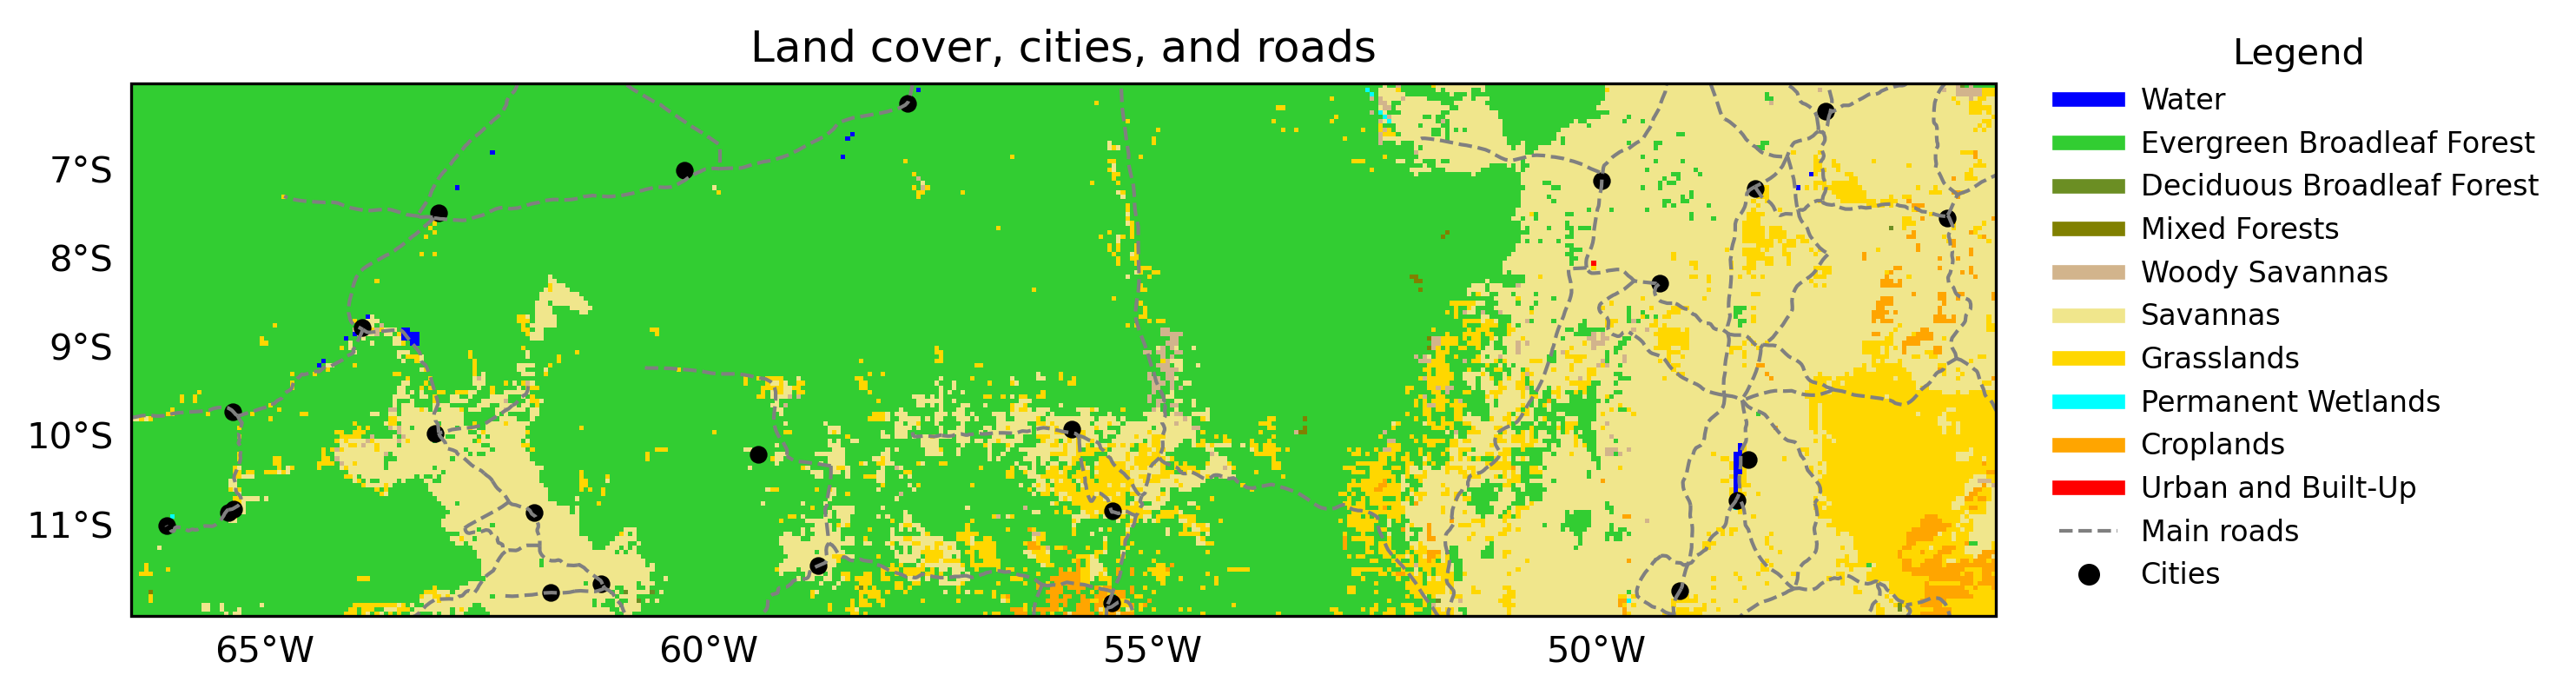

In [15]:

minlon,maxlon,minlat,maxlat,roads,cities,ds_subset,cmap,norm,filtered_colors,filtered_land_cover_classes,active_classes = var_plot_landcover()
# Create a figure and axis with a specified map projection (PlateCarree)
fig = plt.figure(figsize=(10, 3), dpi=300)  # Set figure size and resolution
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())  # Define axis with projection

# Map limits
# Set the map extent based on the predefined latitude and longitude bounds
ax.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())  # Define map's region

# Add main roadas
# Plot the main roads (from shapefile) on the map with custom line style
roads.plot(ax=ax, transform=ccrs.PlateCarree(), color="gray", linestyle="--", linewidth=1.0, label="Main roads")

# Add cities
# Scatter plot cities with specific formatting on the map
ax.scatter(
    cities.geometry.x, cities.geometry.y,  # X and Y coordinates of cities
    color="black", s=15,  # Color black and set size for city points
    transform=ccrs.PlateCarree(),  # Specify projection for the city points
    label="Cities"  # Label for the legend
)


# Add gridlines with labels
gl = ax.gridlines(draw_labels=True)  # Add gridlines to the map
gl.top_labels = gl.right_labels = False  # Disable labels at the top and right of the map
gl.bottom_labels = gl.left_labels = True  # Enable labels at the bottom and left
gl.xlines = False  # Hide the vertical gridlines
gl.ylines = False  # Hide the horizontal gridlines

# Customize the gridline intervals
gl.xlocator = mticker.MultipleLocator(5)  # Longitude labels every 5 degrees
gl.ylocator = mticker.MultipleLocator(1)  # Latitude labels every 1 degree

# Plot the land cover data on the map
plot = ds_subset["Majority_Land_Cover_Type_1"].plot(
    ax=ax,
    x="longitude",  # X-axis (longitude) for the land cover data
    y="latitude",  # Y-axis (latitude) for the land cover data
    cmap=cmap,  # Colormap for the land cover data
    norm=norm,  # Normalization for the colormap
    add_colorbar=False,  # Disable colorbar since it's not needed in this case
    zorder=0,  # Set the z-order for layering (land cover data in the background)
)

# Create custom legend handles for land cover types
# These handles represent the different filtered land cover classes in the legend
handles = [
    plt.Line2D([0], [0], color=filtered_colors[i], lw=4, label=f"{filtered_land_cover_classes[cls]}")
    for i, cls in enumerate(active_classes)  # Iterate over the active land cover classes
]

# Add additional handles for the other map features (roads, cities)
additional_handles = [
    plt.Line2D([0], [0], color="gray", lw=1.0, linestyle="--", label="Main roads"),
    plt.Line2D([0], [0], color="black", marker="o", markersize=5, linestyle="", label="Cities")
]

# Combine the legend handles for all map features
handles.extend(additional_handles)

# Add the legend to the plot
ax.legend(
    handles=handles,  # Use the combined list of handles for the legend
    loc="lower left",  # Position the legend at the bottom left
    bbox_to_anchor=(1.02, 0),  # Position the legend outside the plot to the right
    title="Legend",  # Set the title for the legend
    fontsize=8,  # Set the font size for the legend text
    title_fontsize=10,  # Set the font size for the legend title
    frameon=False  # Disable the border around the legend
)

# Add bold text to the upper-left corner of the map
#ax.text(
#    0.01, 0.99,  # Relative position in axes coordinates (0=left/bottom, 1=right/top)
#    'B)',  # Text content
#    transform=ax.transAxes,  # Use axes-relative coordinates for positioning
#    fontsize=12,  # Set font size for the annotation
#    fontweight='bold',  # Make the text bold
#    ha='left',  # Horizontal alignment to the left
#    va='top',  # Vertical alignment to the top
#)

# Set the title for the plot
plt.title("Land cover, cities, and roads")  # Set title text

# Adjust the layout to prevent overlap of plot elements
plt.tight_layout()

# Save the plot to a PNG file
#plt.savefig('filename.png')

# Display the plot
plt.show()

In [16]:
def plot_results_data(flight_number, flight_date,
                     filtered_ds_psap_aux, Mass_absortion_eff, 
                     ds_neph_datetime, Mass_scattering_eff,
                     ):
    
    fig = plt.figure(figsize=(12, 8))  # Slightly wider and taller

    # Formatter for scientific notation
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    
    # Define plot positions
    # Improved subplot positions
    positions = {
        "sct_coef": [0.07, 0.65, 0.4, 0.28],   # Top-left
        "abs_coef": [0.53, 0.65, 0.4, 0.28],   # Top-right
        "map": [0.2, 0.15, 0.6, 0.35],         # Center-bottom
    }

    # First plot - Stacked Area Plot
    # Third plot - Absorption Coefficient
    ax1 = fig.add_axes(positions["sct_coef"])
    ax1.plot(filtered_ds_psap_aux['Time'], Mass_absortion_eff, color="r", marker='.', linewidth=0)
    ax1.set_xlabel("Time")
    ax1.set_ylabel(r'Mass Absorption Coefficient (m²/g)')
    ax1.set_title(f"Flight {flight_number} - {flight_date}")
    ax1.yaxis.set_major_formatter(formatter)
    ax1.tick_params(axis='x', rotation=45)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as hours:minutes
    ax1.grid()


    # Second plot - Absorption Coefficient
    ax2 = fig.add_axes(positions["abs_coef"])
    ax2.plot(ds_neph_datetime['Times'], Mass_scattering_eff, color="r", marker='.', linewidth=0)
    ax2.set_xlabel("Time")
    ax2.set_ylabel(r'Mass Scattering Coefficient (m²/g)')
    ax2.set_title(f"Flight {flight_number} - {flight_date}")
    ax2.yaxis.set_major_formatter(formatter)
    ax2.tick_params(axis='x', rotation=45)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as hours:minutes
    ax2.grid()

    # Fifth plot - Flight Track Map (Cartopy)
    ax3 = fig.add_axes(positions["map"], projection=ccrs.PlateCarree())
    ax3.set_extent([-66.5, -45.5, -12, -6], crs=ccrs.PlateCarree())
    ax3.coastlines()
    ax3.add_feature(cfeature.BORDERS, linestyle=':')
    ax3.add_feature(cfeature.LAND)
    ax3.add_feature(cfeature.OCEAN)
    # Add gridlines with only bottom and left labels
    gl = ax3.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False


    # Extract coordinates
    lat_valid = ds_psap['LAT_GIN']
    lon_valid = ds_psap['LON_GIN']
    
    # Filter out minimum values (e.g., invalid values like -999)
    valid_mask = (lat_valid < 0) & (lon_valid < -30)
    lat_filtered = lat_valid.where(valid_mask, drop=True)
    lon_filtered = lon_valid.where(valid_mask, drop=True)
    
    # Plot
    # ax5.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())
    ax3.scatter(lon_filtered, lat_filtered, s=1, transform=ccrs.PlateCarree())
    ax3.set_title(f"Flight {flight_number} - Flight Track")


    # Save and show the figure
    #plt.tight_layout()
    plt.savefig(f'./Results_plots/flight_coefficients_{flight_number}_v1.png', dpi=300)
    print(f"Figure saved as flight_coefficients_{flight_number}_v1.png")
    #plt.show()

    return

In [17]:
def plot_results_data_v2(flight_number, flight_date,
                     filtered_ds_psap_aux, Mass_absortion_eff, 
                     ds_neph_datetime, Mass_scattering_eff,
                     mean_abs_eff, mean_sct_eff):

    minlon,maxlon,minlat,maxlat,roads,cities,ds_subset,cmap,norm,filtered_colors,filtered_land_cover_classes,active_classes = var_plot_landcover()
    
    fig = plt.figure(figsize=(12, 8))  # Slightly wider and taller

    # Formatter for scientific notation
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))

    # Define plot positions
    positions = {
        "sct_coef": [0.07, 0.60, 0.4, 0.33],      # Top-left
        "abs_coef": [0.53, 0.60, 0.4, 0.33],      # Top-right
        "map": [0.13, 0.15, 0.6, 0.30],            # Center-bottom
        "land_cover": [0.2, 0.03, 0.6, 0.30],  # Below the map with a small gap (0.05)
    }

    # First plot - Absorption Coefficient
    label_text_abs = f"Mean: {mean_abs_eff:.2f} m²/g"
    ax1 = fig.add_axes(positions["sct_coef"])
    ax1.plot(Mass_absortion_eff['time'], Mass_absortion_eff.values, color="r", marker='.', linewidth=0,label=label_text_abs)
    ax1.set_xlabel("Time")
    ax1.set_ylabel(r'Mass Absorption Coefficient (m²/g)')
    ax1.set_title(f"Flight {flight_number} - {flight_date}")
    ax1.yaxis.set_major_formatter(formatter)
    ax1.tick_params(axis='x', rotation=45)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as hours:minutes
    ax1.grid()
    ax1.legend(loc="upper left")


    # Second plot - Absorption Coefficient
    label_text_sct = f"Mean: {mean_sct_eff:.2f} m²/g"
    ax2 = fig.add_axes(positions["abs_coef"])
    ax2.plot(ds_neph_datetime['Times'], Mass_scattering_eff, color="r", marker='.', linewidth=0,label=label_text_sct)
    ax2.set_xlabel("Time")
    ax2.set_ylabel(r'Mass Scattering Coefficient (m²/g)')
    ax2.set_title(f"Flight {flight_number} - {flight_date}")
    ax2.yaxis.set_major_formatter(formatter)
    ax2.tick_params(axis='x', rotation=45)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as hours:minutes
    ax2.grid()
    ax2.legend(loc="upper left")

    # Fifth plot - Flight Track Map (Cartopy)
    ax3 = fig.add_axes(positions["map"], projection=ccrs.PlateCarree())
    ax3.set_extent([minlon,maxlon,minlat,maxlat], crs=ccrs.PlateCarree())
    #ax3.coastlines()
    #ax3.add_feature(cfeature.BORDERS, linestyle=':')
    #ax3.add_feature(cfeature.LAND)
    #ax3.add_feature(cfeature.OCEAN)
    # Add gridlines with only bottom and left labels
    #gl = ax3.gridlines(draw_labels=True)
    #gl.top_labels = False
    #gl.right_labels = False


    # Extract coordinates
    lat_valid = ds_psap['LAT_GIN']
    lon_valid = ds_psap['LON_GIN']
    
    # Filter out minimum values (e.g., invalid values like -999)
    valid_mask = (lat_valid < 0) & (lon_valid < -30)
    lat_filtered = lat_valid.where(valid_mask, drop=True)
    lon_filtered = lon_valid.where(valid_mask, drop=True)


    
    # Convert to NumPy arrays for math operations
    lat = lat_filtered.values
    lon = lon_filtered.values
    
    # Ensure no NaNs remain
    valid_points = (~np.isnan(lat)) & (~np.isnan(lon))
    lat = lat[valid_points]
    lon = lon[valid_points]

    # Subsample to reduce arrow density (e.g., keep every 10th point)
    step = 35000
    lon_sub = lon[::step]
    lat_sub = lat[::step]
    dx = np.diff(lon[::step])
    dy = np.diff(lat[::step])
    
    # Compute midpoints for arrow positions
    lon_mid = lon_sub[:-1] + dx / 2
    lat_mid = lat_sub[:-1] + dy / 2
        
    
    # Plot the flight path line
    ax3.plot(lon, lat, transform=ccrs.PlateCarree(), color="purple", linewidth=1.0, label="Flight track")
    
    # Plot arrows to indicate direction
    ax3.quiver(
        lon_mid, lat_mid, dx, dy,
        transform=ccrs.PlateCarree(),
        scale_units='xy', angles='xy', scale=2.5, color='purple', width=0.002
    )
    
    # Plot
    # ax5.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())
    #ax3.scatter(lon_filtered, lat_filtered, s=4, transform=ccrs.PlateCarree(),color="purple", linewidth=2.0, label="Flight track")
    


    #ax4 = fig.add_axes(positions["land_cover"], projection=ccrs.PlateCarree())
    #ax4.set_extent([minlon,maxlon,minlat,maxlat], crs=ccrs.PlateCarree())
    # Plot the main roads (from shapefile) on the map with custom line style
    roads.plot(ax=ax3, transform=ccrs.PlateCarree(), color="gray", linestyle="--", linewidth=1.0, label="Main roads")
    
    # Add cities
    # Scatter plot cities with specific formatting on the map
    ax3.scatter(
        cities.geometry.x, cities.geometry.y,  # X and Y coordinates of cities
        color="black", s=15,  # Color black and set size for city points
        transform=ccrs.PlateCarree(),  # Specify projection for the city points
        label="Cities"  # Label for the legend
    )
    
    
    # Add gridlines with labels
    gl = ax3.gridlines(draw_labels=True)  # Add gridlines to the map
    gl.top_labels = gl.right_labels = False  # Disable labels at the top and right of the map
    gl.bottom_labels = gl.left_labels = True  # Enable labels at the bottom and left
    gl.xlines = False  # Hide the vertical gridlines
    gl.ylines = False  # Hide the horizontal gridlines
    
    # Customize the gridline intervals
    gl.xlocator = mticker.MultipleLocator(5)  # Longitude labels every 5 degrees
    gl.ylocator = mticker.MultipleLocator(1)  # Latitude labels every 1 degree
    
    # Plot the land cover data on the map
    plot = ds_subset["Majority_Land_Cover_Type_1"].plot(
        ax=ax3,
        x="longitude",  # X-axis (longitude) for the land cover data
        y="latitude",  # Y-axis (latitude) for the land cover data
        cmap=cmap,  # Colormap for the land cover data
        norm=norm,  # Normalization for the colormap
        add_colorbar=False,  # Disable colorbar since it's not needed in this case
        zorder=0,  # Set the z-order for layering (land cover data in the background)
    )
    
    # Create custom legend handles for land cover types
    # These handles represent the different filtered land cover classes in the legend
    handles = [
        plt.Line2D([0], [0], color=filtered_colors[i], lw=4, label=f"{filtered_land_cover_classes[cls]}")
        for i, cls in enumerate(active_classes)  # Iterate over the active land cover classes
    ]
    
    # Add additional handles for the other map features (roads, cities)
    additional_handles = [
        plt.Line2D([0], [0], color="gray", lw=1.0, linestyle="--", label="Main roads"),
        plt.Line2D([0], [0], color="black", marker="o", markersize=5, linestyle="", label="Cities"),
        plt.Line2D([0], [0], color="purple", lw=2.0, linestyle="-", label="Flight Track")
    ]
    
    # Combine the legend handles for all map features
    handles.extend(additional_handles)
    
    # Add the legend to the plot
    ax3.legend(
        handles=handles,  # Use the combined list of handles for the legend
        loc="lower left",  # Position the legend at the bottom left
        bbox_to_anchor=(1.02, -0.05),  # Position the legend outside the plot to the right
        title="Legend",  # Set the title for the legend
        fontsize=8,  # Set the font size for the legend text
        title_fontsize=8,  # Set the font size for the legend title
        frameon=False  # Disable the border around the legend
    )
    ax3.set_title(f"Flight {flight_number} - Flight Track over Land cover")


    # Save and show the figure
    #plt.tight_layout()
    plt.savefig(f'./Results_plots/flight_coefficients_{flight_number}_v3.png', dpi=300)
    print(f"Figure saved as flight_coefficients_{flight_number}_v3.png")
    #plt.show()

    return

In [26]:
def plot_results_data_v3(flight_number, flight_date,
                     abs_coeff_uncertainty, Mass_absortion_eff, 
                     ds_neph_datetime, Mass_scattering_eff, sct_coeff_uncertainty,
                     mean_abs_eff, mean_sct_eff):

    minlon,maxlon,minlat,maxlat,roads,cities,ds_subset,cmap,norm,filtered_colors,filtered_land_cover_classes,active_classes = var_plot_landcover()
    
    fig = plt.figure(figsize=(12, 8))  # Slightly wider and taller

    # Formatter for scientific notation
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))

    # Define plot positions
    positions = {
        "sct_coef": [0.07, 0.60, 0.4, 0.33],      # Top-left
        "abs_coef": [0.53, 0.60, 0.4, 0.33],      # Top-right
        "map": [0.13, 0.15, 0.6, 0.30],            # Center-bottom
        "land_cover": [0.2, 0.03, 0.6, 0.30],  # Below the map with a small gap (0.05)
    }

    # First plot - Absorption Coefficient
    label_text_abs = f"Mean: {mean_abs_eff:.2f} m²/g"
    ax1 = fig.add_axes(positions["sct_coef"])
    # Error bar plot
    ax1.errorbar(
        Mass_absortion_eff['time'].values,
        Mass_absortion_eff.values,
        yerr=3*abs_coeff_uncertainty.values,
        fmt='.',
        markersize=2,      # Smaller marker size
        color='r',
        ecolor='gray',              # Color of error bars
        elinewidth=1,
        capsize=2,
        label=label_text_abs
    )

    
    ax1.set_xlabel("Time")
    ax1.set_ylabel(r'Mass Absorption Coefficient (m²/g)')
    ax1.set_title(f"Flight {flight_number} - {flight_date}")
    ax1.yaxis.set_major_formatter(formatter)
    ax1.tick_params(axis='x', rotation=45)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as hours:minutes
    ax1.grid()
    ax1.legend(loc="upper left")


    # Second plot - Absorption Coefficient
    label_text_sct = f"Mean: {mean_sct_eff:.2f} m²/g"
    ax2 = fig.add_axes(positions["abs_coef"])
    #ax2.plot(ds_neph_datetime['Times'], Mass_scattering_eff, color="r", marker='.', linewidth=0,label=label_text_sct)

    ax2.errorbar(
        Mass_scattering_eff['time'].values,
        Mass_scattering_eff.values,
        yerr=3*sct_coeff_uncertainty.values,
        fmt='.',
        markersize=2,      # Smaller marker size
        color='r',
        ecolor='gray',              # Color of error bars
        elinewidth=1,
        capsize=2,
        label=label_text_sct
    )
    ax2.set_xlabel("Time")
    ax2.set_ylabel(r'Mass Scattering Coefficient (m²/g)')
    ax2.set_title(f"Flight {flight_number} - {flight_date}")
    ax2.yaxis.set_major_formatter(formatter)
    ax2.tick_params(axis='x', rotation=45)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as hours:minutes
    ax2.grid()
    ax2.legend(loc="upper left")

    # Fifth plot - Flight Track Map (Cartopy)
    ax3 = fig.add_axes(positions["map"], projection=ccrs.PlateCarree())
    ax3.set_extent([minlon,maxlon,minlat,maxlat], crs=ccrs.PlateCarree())
    #ax3.coastlines()
    #ax3.add_feature(cfeature.BORDERS, linestyle=':')
    #ax3.add_feature(cfeature.LAND)
    #ax3.add_feature(cfeature.OCEAN)
    # Add gridlines with only bottom and left labels
    #gl = ax3.gridlines(draw_labels=True)
    #gl.top_labels = False
    #gl.right_labels = False


    # Extract coordinates
    lat_valid = ds_psap['LAT_GIN']
    lon_valid = ds_psap['LON_GIN']
    
    # Filter out minimum values (e.g., invalid values like -999)
    valid_mask = (lat_valid < 0) & (lon_valid < -30)
    lat_filtered = lat_valid.where(valid_mask, drop=True)
    lon_filtered = lon_valid.where(valid_mask, drop=True)


    
    # Convert to NumPy arrays for math operations
    lat = lat_filtered.values
    lon = lon_filtered.values
    
    # Ensure no NaNs remain
    valid_points = (~np.isnan(lat)) & (~np.isnan(lon))
    lat = lat[valid_points]
    lon = lon[valid_points]

    # Subsample to reduce arrow density (e.g., keep every 10th point)
    step = 35000
    lon_sub = lon[::step]
    lat_sub = lat[::step]
    dx = np.diff(lon[::step])
    dy = np.diff(lat[::step])
    
    # Compute midpoints for arrow positions
    lon_mid = lon_sub[:-1] + dx / 2
    lat_mid = lat_sub[:-1] + dy / 2
        
    
    # Plot the flight path line
    ax3.plot(lon, lat, transform=ccrs.PlateCarree(), color="purple", linewidth=1.0, label="Flight track")
    
    # Plot arrows to indicate direction
    ax3.quiver(
        lon_mid, lat_mid, dx, dy,
        transform=ccrs.PlateCarree(),
        scale_units='xy', angles='xy', scale=2.5, color='purple', width=0.002
    )
    
    # Plot
    # ax5.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())
    #ax3.scatter(lon_filtered, lat_filtered, s=4, transform=ccrs.PlateCarree(),color="purple", linewidth=2.0, label="Flight track")
    


    #ax4 = fig.add_axes(positions["land_cover"], projection=ccrs.PlateCarree())
    #ax4.set_extent([minlon,maxlon,minlat,maxlat], crs=ccrs.PlateCarree())
    # Plot the main roads (from shapefile) on the map with custom line style
    roads.plot(ax=ax3, transform=ccrs.PlateCarree(), color="gray", linestyle="--", linewidth=1.0, label="Main roads")
    
    # Add cities
    # Scatter plot cities with specific formatting on the map
    ax3.scatter(
        cities.geometry.x, cities.geometry.y,  # X and Y coordinates of cities
        color="black", s=15,  # Color black and set size for city points
        transform=ccrs.PlateCarree(),  # Specify projection for the city points
        label="Cities"  # Label for the legend
    )
    
    
    # Add gridlines with labels
    gl = ax3.gridlines(draw_labels=True)  # Add gridlines to the map
    gl.top_labels = gl.right_labels = False  # Disable labels at the top and right of the map
    gl.bottom_labels = gl.left_labels = True  # Enable labels at the bottom and left
    gl.xlines = False  # Hide the vertical gridlines
    gl.ylines = False  # Hide the horizontal gridlines
    
    # Customize the gridline intervals
    gl.xlocator = mticker.MultipleLocator(5)  # Longitude labels every 5 degrees
    gl.ylocator = mticker.MultipleLocator(1)  # Latitude labels every 1 degree
    
    # Plot the land cover data on the map
    plot = ds_subset["Majority_Land_Cover_Type_1"].plot(
        ax=ax3,
        x="longitude",  # X-axis (longitude) for the land cover data
        y="latitude",  # Y-axis (latitude) for the land cover data
        cmap=cmap,  # Colormap for the land cover data
        norm=norm,  # Normalization for the colormap
        add_colorbar=False,  # Disable colorbar since it's not needed in this case
        zorder=0,  # Set the z-order for layering (land cover data in the background)
    )
    
    # Create custom legend handles for land cover types
    # These handles represent the different filtered land cover classes in the legend
    handles = [
        plt.Line2D([0], [0], color=filtered_colors[i], lw=4, label=f"{filtered_land_cover_classes[cls]}")
        for i, cls in enumerate(active_classes)  # Iterate over the active land cover classes
    ]
    
    # Add additional handles for the other map features (roads, cities)
    additional_handles = [
        plt.Line2D([0], [0], color="gray", lw=1.0, linestyle="--", label="Main roads"),
        plt.Line2D([0], [0], color="black", marker="o", markersize=5, linestyle="", label="Cities"),
        plt.Line2D([0], [0], color="purple", lw=2.0, linestyle="-", label="Flight Track")
    ]
    
    # Combine the legend handles for all map features
    handles.extend(additional_handles)
    
    # Add the legend to the plot
    ax3.legend(
        handles=handles,  # Use the combined list of handles for the legend
        loc="lower left",  # Position the legend at the bottom left
        bbox_to_anchor=(1.02, -0.05),  # Position the legend outside the plot to the right
        title="Legend",  # Set the title for the legend
        fontsize=8,  # Set the font size for the legend text
        title_fontsize=8,  # Set the font size for the legend title
        frameon=False  # Disable the border around the legend
    )
    ax3.set_title(f"Flight {flight_number} - Flight Track over Land cover")


    # Save and show the figure
    #plt.tight_layout()
    plt.savefig(f'./flight_coefficients_{flight_number}_v5.png', dpi=300)
    print(f"Figure saved as flight_coefficients_{flight_number}_v5.png")
    #plt.show()

    return

In [27]:
ds_neph = xr.open_dataset(filtered_neph[0],decode_times=False)

In [28]:
ds_neph = ds_neph.set_coords('neph_spm')
ds_neph

<xarray.Dataset> Size: 2MB
Dimensions:   (time: 21520)
Coordinates:
    neph_spm  (time) float64 172kB ...
Dimensions without coordinates: time
Data variables:
    TSC_BLUU  (time) float64 172kB ...
    TSC_GRNU  (time) float64 172kB ...
    TSC_REDU  (time) float64 172kB ...
    BSC_BLUU  (time) float64 172kB ...
    BSC_GRNU  (time) float64 172kB ...
    BSC_REDU  (time) float64 172kB ...
    NEPH_PR   (time) float64 172kB ...
    NEPH_T    (time) float64 172kB ...
    NEPH_HUM  (time) float64 172kB ...
    NEPH_FLO  (time) float64 172kB ...
Attributes:
    description:  Dry neph data NetCDF from SAMBBA. Note neph data in the cor...
    conventions:  NetCDF4
    title:        Dry neph data (some differences from usual core data - ask ...
    institution:  Data provided by the Met Office (recorded via wet neph).
    history:      Created Thu Mar 14 11:52:39 2013
    references:   Anderson and Ogren, AST, 1998 for details on corrections. 
    data_date:    20120918
    sample_line:  Inlet -> nafion drier -> dry neph -> humidifier -> wet neph...
    comment:      Note that the Met Office TSI3563 was used in place of the F...

In [29]:
ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(filtered_sp2[0],filtered_ams[0],filtered_neph[0])
ds_psap = xr.open_dataset(filtered_nc[0])

In [30]:
ds_psap_matched,tm_psap_match,tm_psap_match_unc,test=calculate_absortion_eff_v3(ds_sp2,ds_ams,ds_psap)
test

<xarray.Dataset> Size: 891kB
Dimensions:         (data_point: 82, sps32: 32, sps01: 1, sps04: 4, sps02: 2,
                     sps64: 64)
Coordinates:
  * data_point      (data_point) datetime64[ns] 656B 2012-09-18T13:17:00 ... ...
Dimensions without coordinates: sps32, sps01, sps04, sps02, sps64
Data variables: (12/140)
    IAS_RVSM        (data_point, sps32, sps01) float32 10kB 109.6 ... 84.52
    IAS_RVSM_FLAG   (data_point, sps32, sps01) float32 10kB 0.0 0.0 ... 0.0 0.0
    TAS_RVSM        (data_point, sps32, sps01) float32 10kB 124.8 ... 88.85
    TAS_RVSM_FLAG   (data_point, sps32, sps01) float32 10kB 0.0 0.0 ... 0.0 0.0
    TAT_DI_R        (data_point, sps32, sps01) float32 10kB 288.1 ... 301.8
    TAT_DI_R_FLAG   (data_point, sps32, sps01) float32 10kB 0.0 0.0 ... 0.0 0.0
    ...              ...
    TDEW_C_U        (data_point, sps01) float32 328B 0.347 0.2948 ... 0.3587
    TDEW_C_U_FLAG   (data_point, sps01) float32 328B 0.05 0.1 0.1 ... 0.0 0.0
    U_NOTURB        (data_point, sps01) float32 328B 1.563 1.596 ... 2.228 1.401
    U_NOTURB_FLAG   (data_point, sps01) float32 328B 0.95 0.0 0.0 ... 1.2 2.7
    V_NOTURB        (data_point, sps01) float32 328B -7.775 -7.346 ... -3.222
    V_NOTURB_FLAG   (data_point, sps01) float32 328B 0.95 0.0 0.0 ... 1.2 2.7
Attributes: (12/22)
    conventions:         CF-1.0
    title:               Data from b734 on 18-SEP-12
    institution:         FAAM
    source:              FAAM BAe-146 Aircraft Data
    references:          http://www.faam.ac.uk
    Cal_Input_Files:     Input files:\n/home/tardis/data/fltcons/flight-cst_f...
    ...                  ...
    Tardis_Version:      v004
    Format_Version:      1.00
    comment:             FAAM data core_faam_yyyymmdd_vnnn_rn_cnnn.nc\n where...
    Data_Date:           20130619
    TimeInterval:        08:52:02-16:02:21
    History:             Dataset /home/tardis/data/ncdata/core_faam_20120918_...

In [31]:
ds_neph_matched,tm_neph_match,tm_neph_match_unc=calculate_scatering_eff_v2(ds_sp2,ds_ams,ds_neph)
ds_neph_matched

<xarray.Dataset> Size: 19kB
Dimensions:   (time: 201)
Coordinates:
  * time      (time) datetime64[ns] 2kB 2012-09-18T12:41:00 ... 2012-09-18T16...
Data variables:
    neph_spm  (time) float64 2kB 4.569e+04 4.575e+04 ... 5.763e+04 5.769e+04
    TSC_BLUU  (time) float64 2kB 2.302e-06 2.285e-06 ... 8.9e-05 9.135e-05
    TSC_GRNU  (time) float64 2kB 1.995e-06 1.661e-06 ... 6.451e-05 6.362e-05
    TSC_REDU  (time) float64 2kB 1.277e-06 1.126e-06 ... 3.957e-05 3.874e-05
    BSC_BLUU  (time) float64 2kB 5.43e-08 -2.042e-07 ... 9.37e-06 9.388e-06
    BSC_GRNU  (time) float64 2kB 4.939e-08 1.106e-07 ... 7.901e-06 7.957e-06
    BSC_REDU  (time) float64 2kB 2.951e-07 1.171e-07 ... 6.963e-06 6.784e-06
    NEPH_PR   (time) float64 2kB 421.4 418.0 417.1 422.7 ... 971.1 979.2 986.4
    NEPH_T    (time) float64 2kB 301.1 301.0 300.9 300.8 ... 299.7 299.7 299.7
    NEPH_HUM  (time) float64 2kB 5.447 5.107 4.773 4.487 ... 59.08 60.35 62.0
    NEPH_FLO  (time) float64 2kB 15.0 15.0 15.0 15.0 ... 15.0 15.0 15.0 15.0
Attributes:
    description:  Dry neph data NetCDF from SAMBBA. Note neph data in the cor...
    conventions:  NetCDF4
    title:        Dry neph data (some differences from usual core data - ask ...
    institution:  Data provided by the Met Office (recorded via wet neph).
    history:      Created Thu Mar 14 11:52:39 2013
    references:   Anderson and Ogren, AST, 1998 for details on corrections. 
    data_date:    20120918
    sample_line:  Inlet -> nafion drier -> dry neph -> humidifier -> wet neph...
    comment:      Note that the Met Office TSI3563 was used in place of the F...

In [32]:
ds_psap_matched_time = test["data_point"].values  # Reference timestamps
ds_neph_matched_time = ds_neph_matched["time"].values
common_times = np.intersect1d(ds_psap_matched_time, ds_neph_matched_time)

ds_psap_matched = test.sel(data_point=common_times)
ds_neph_matched_test = ds_neph_matched.sel(time=common_times)

#mask = ds_psap_matched["PSAP_LIN"].notnull()
#ds_neph_matched_test = ds_neph_matched.where(mask, drop=True)
#print(len(ds_neph_matched["time"].values))
#print(len(ds_neph_matched_test['time'].values))
ds_neph_matched

<xarray.Dataset> Size: 19kB
Dimensions:   (time: 201)
Coordinates:
  * time      (time) datetime64[ns] 2kB 2012-09-18T12:41:00 ... 2012-09-18T16...
Data variables:
    neph_spm  (time) float64 2kB 4.569e+04 4.575e+04 ... 5.763e+04 5.769e+04
    TSC_BLUU  (time) float64 2kB 2.302e-06 2.285e-06 ... 8.9e-05 9.135e-05
    TSC_GRNU  (time) float64 2kB 1.995e-06 1.661e-06 ... 6.451e-05 6.362e-05
    TSC_REDU  (time) float64 2kB 1.277e-06 1.126e-06 ... 3.957e-05 3.874e-05
    BSC_BLUU  (time) float64 2kB 5.43e-08 -2.042e-07 ... 9.37e-06 9.388e-06
    BSC_GRNU  (time) float64 2kB 4.939e-08 1.106e-07 ... 7.901e-06 7.957e-06
    BSC_REDU  (time) float64 2kB 2.951e-07 1.171e-07 ... 6.963e-06 6.784e-06
    NEPH_PR   (time) float64 2kB 421.4 418.0 417.1 422.7 ... 971.1 979.2 986.4
    NEPH_T    (time) float64 2kB 301.1 301.0 300.9 300.8 ... 299.7 299.7 299.7
    NEPH_HUM  (time) float64 2kB 5.447 5.107 4.773 4.487 ... 59.08 60.35 62.0
    NEPH_FLO  (time) float64 2kB 15.0 15.0 15.0 15.0 ... 15.0 15.0 15.0 15.0
Attributes:
    description:  Dry neph data NetCDF from SAMBBA. Note neph data in the cor...
    conventions:  NetCDF4
    title:        Dry neph data (some differences from usual core data - ask ...
    institution:  Data provided by the Met Office (recorded via wet neph).
    history:      Created Thu Mar 14 11:52:39 2013
    references:   Anderson and Ogren, AST, 1998 for details on corrections. 
    data_date:    20120918
    sample_line:  Inlet -> nafion drier -> dry neph -> humidifier -> wet neph...
    comment:      Note that the Met Office TSI3563 was used in place of the F...

/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/mo-non-core/metoffice-neph1_faam_20120918_r1_b734.nc
Figure saved as flight_coefficients_b734_v5.png
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b737-sep-20/mo-non-core/metoffice-neph1_faam_20120920_r1_b737.nc
Figure saved as flight_coefficients_b737_v5.png
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/mo-non-core/metoffice-neph1_faam_20120923_r1_b739.nc
Figure saved as flight_coefficients_b739_v5.png
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b740-sep-25/mo-non-core/metoffice-neph1_faam_20120925_r1_b740.nc
Figure saved as flight_coefficients_b740_v5.png
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b741-sep-26/mo-non-core/metoffice-neph1_faam_20120926_r1_b741.nc


/tmp/ipykernel_1562/4125690940.py:73: RuntimeWarning: Mean of empty slice
  mean_mass_absorption_eff_g = np.nanmean(Mass_absortion_eff)
/srv/conda/envs/notebook/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1562/4125690940.py:78: RuntimeWarning: Mean of empty slice
  mean_mass_scattering_eff_g = np.nanmean(Mass_scattering_eff)


Figure saved as flight_coefficients_b741_v5.png
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b742-sep-27/mo-non-core/metoffice-neph1_faam_20120927_r1_b742.nc
Figure saved as flight_coefficients_b742_v5.png
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b743-sep-27/mo-non-core/metoffice-neph1_faam_20120927_r1_b743.nc
Figure saved as flight_coefficients_b743_v5.png
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b744-sep-28/mo-non-core/metoffice-neph1_faam_20120928_r1_b744.nc
Figure saved as flight_coefficients_b744_v5.png
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b745-sep-28/mo-non-core/metoffice-neph1_faam_20120928_r1_b745.nc
Figure saved as flight_coefficients_b745_v5.png
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b746-sep-29/mo-non-core/metoffice-neph1_faam_20120929_r1_b746.nc
Figure saved as flight_coefficients_b746_v5.png
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b747-oct-01/mo-non-core/met

/tmp/ipykernel_1562/4125690940.py:73: RuntimeWarning: Mean of empty slice
  mean_mass_absorption_eff_g = np.nanmean(Mass_absortion_eff)
/srv/conda/envs/notebook/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1562/4125690940.py:78: RuntimeWarning: Mean of empty slice
  mean_mass_scattering_eff_g = np.nanmean(Mass_scattering_eff)


Figure saved as flight_coefficients_b747_v5.png
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b748-oct-02/mo-non-core/metoffice-neph1_faam_20121002_r1_b748.nc
Figure saved as flight_coefficients_b748_v5.png
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b749-oct-03/mo-non-core/metoffice-neph1_faam_20121003_r1_b749.nc


/tmp/ipykernel_1562/4125690940.py:73: RuntimeWarning: Mean of empty slice
  mean_mass_absorption_eff_g = np.nanmean(Mass_absortion_eff)
/srv/conda/envs/notebook/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1562/4125690940.py:78: RuntimeWarning: Mean of empty slice
  mean_mass_scattering_eff_g = np.nanmean(Mass_scattering_eff)


Figure saved as flight_coefficients_b749_v5.png
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b750-oct-03/mo-non-core/metoffice-neph1_faam_20121003_r1_b750.nc


/tmp/ipykernel_1562/4125690940.py:73: RuntimeWarning: Mean of empty slice
  mean_mass_absorption_eff_g = np.nanmean(Mass_absortion_eff)
/srv/conda/envs/notebook/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1562/4125690940.py:78: RuntimeWarning: Mean of empty slice
  mean_mass_scattering_eff_g = np.nanmean(Mass_scattering_eff)


Figure saved as flight_coefficients_b750_v5.png


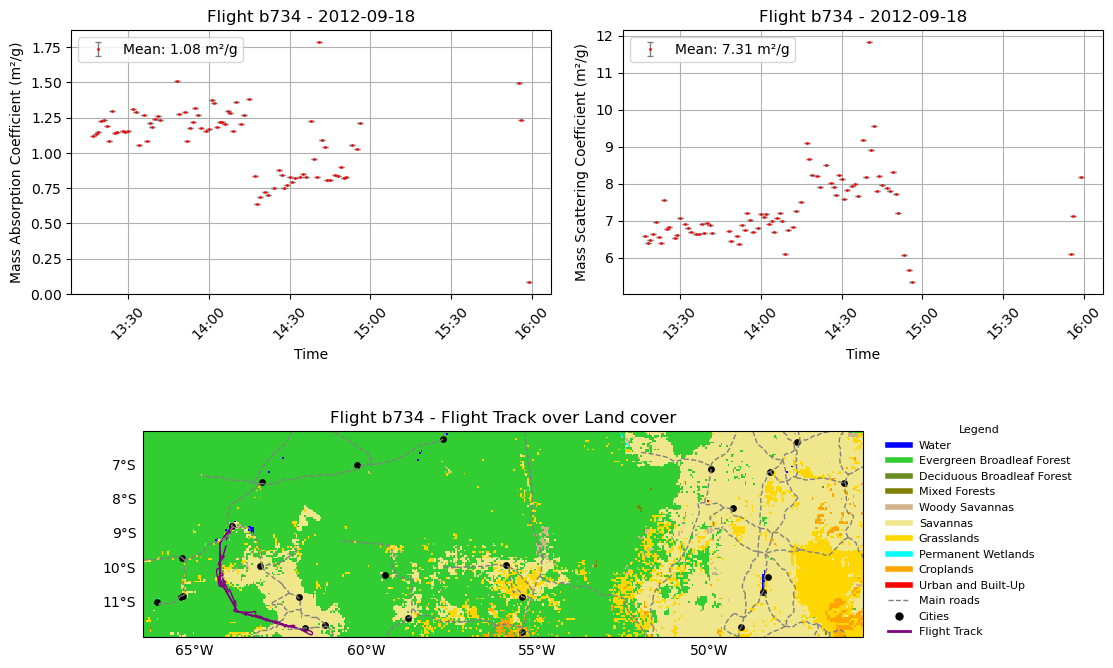

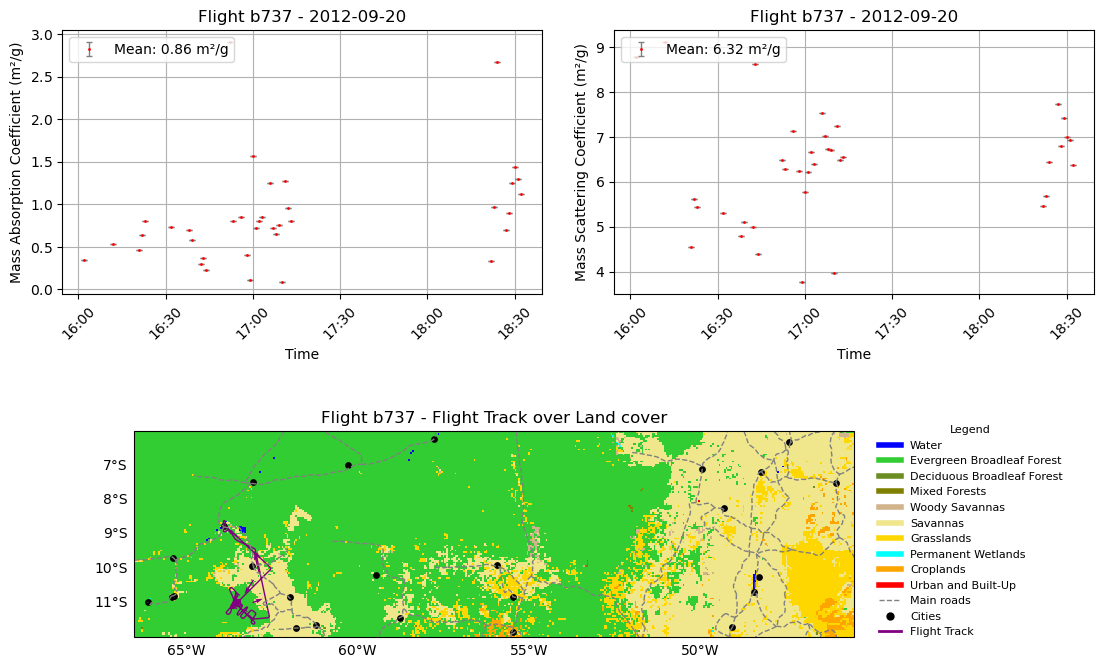

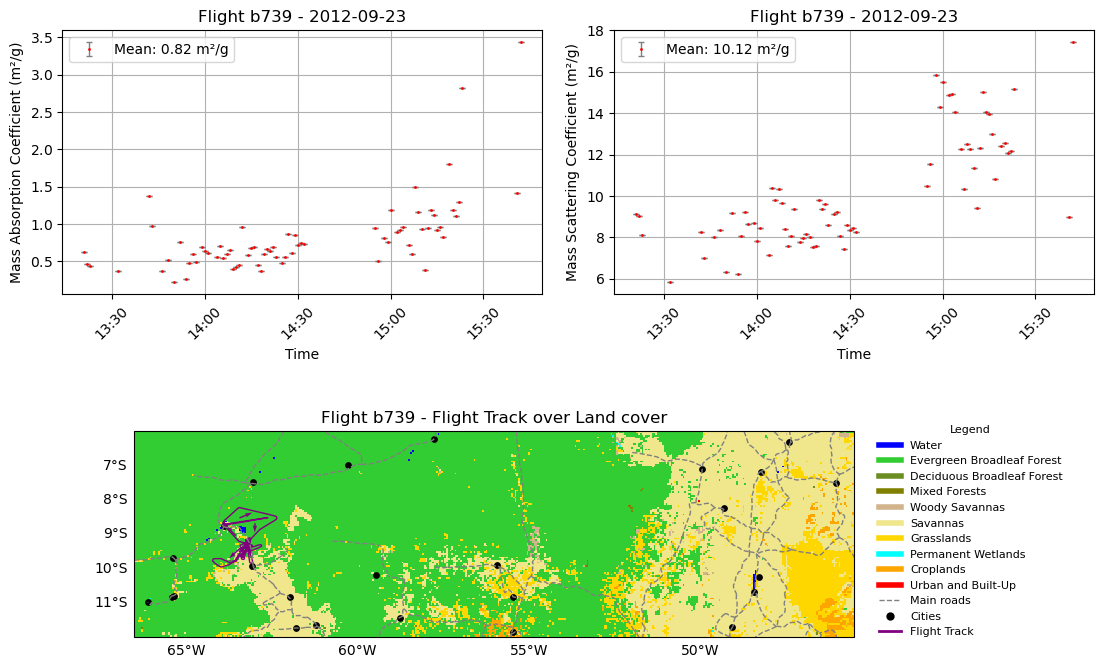

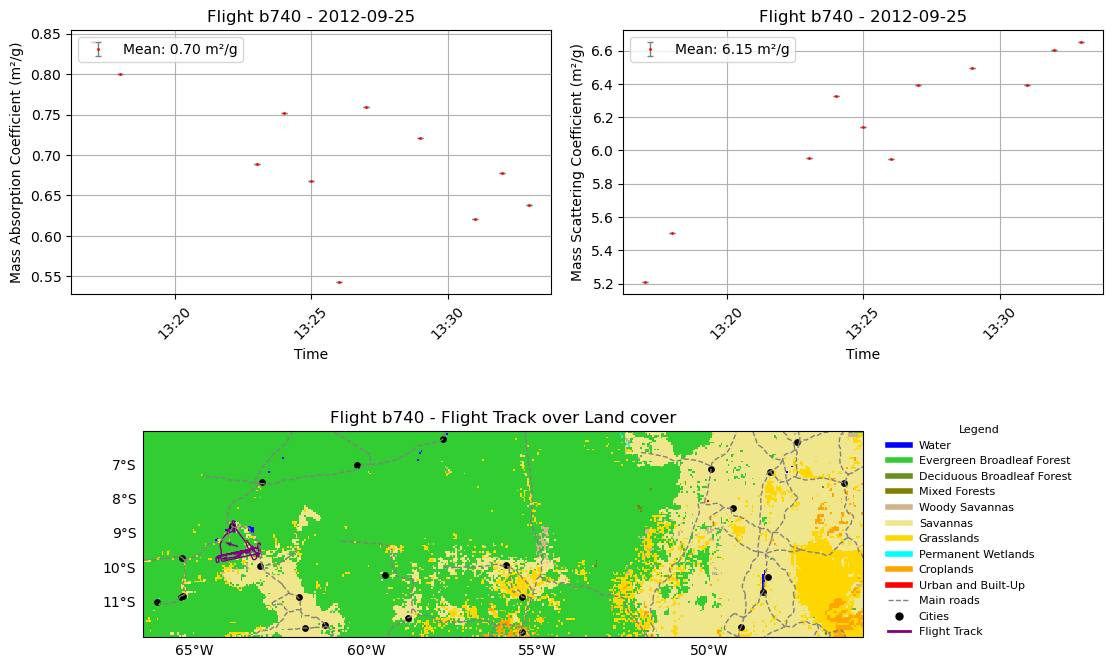

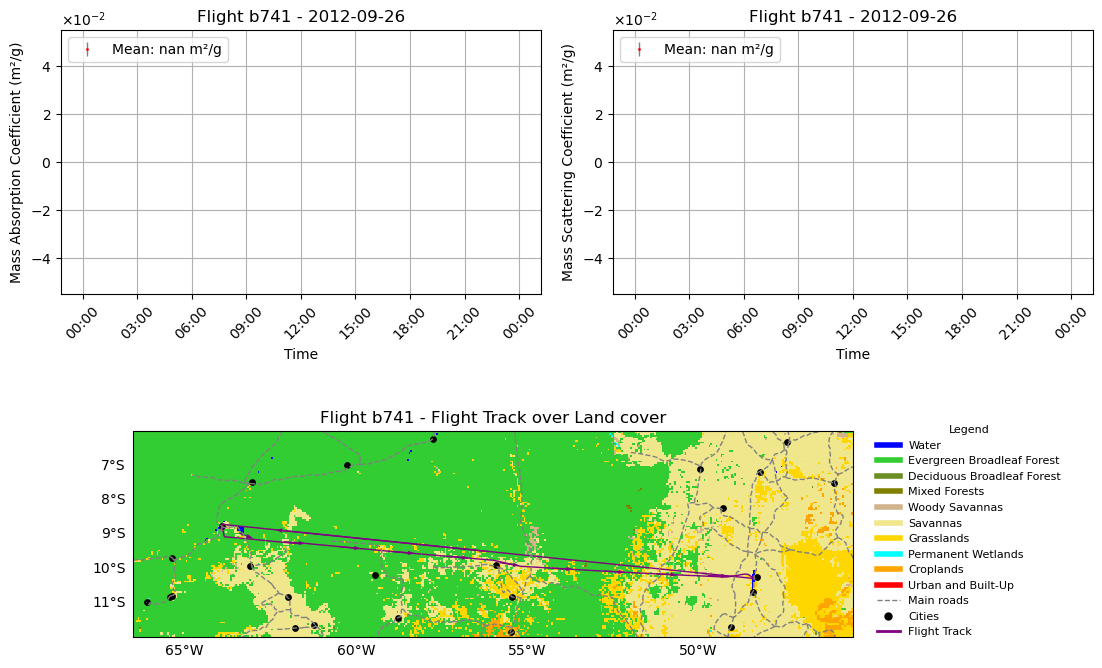

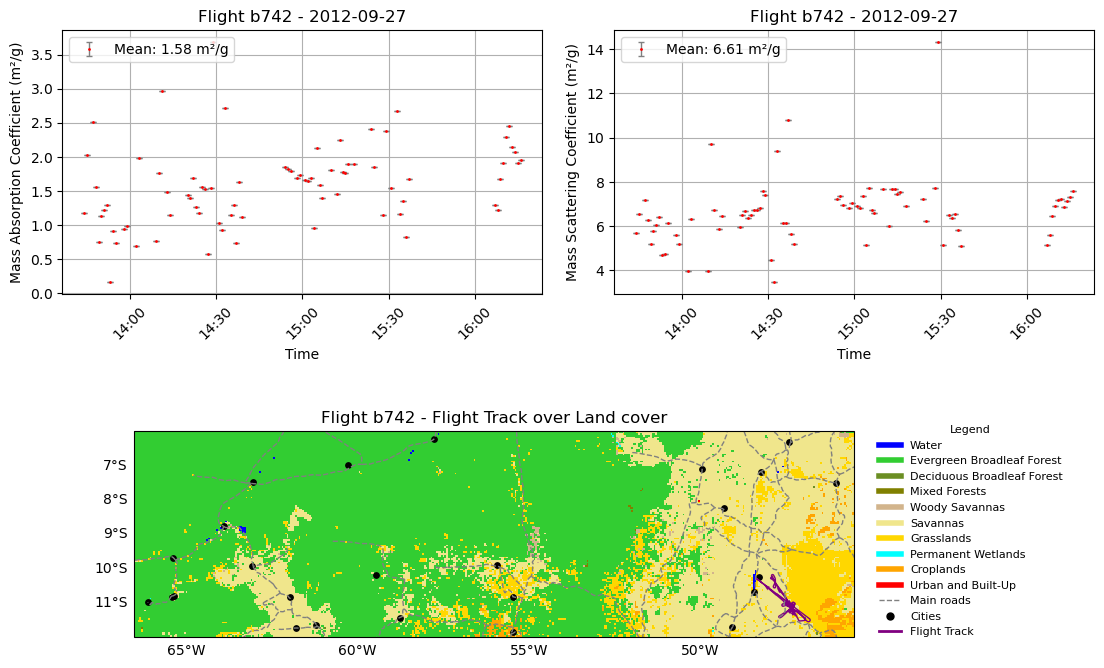

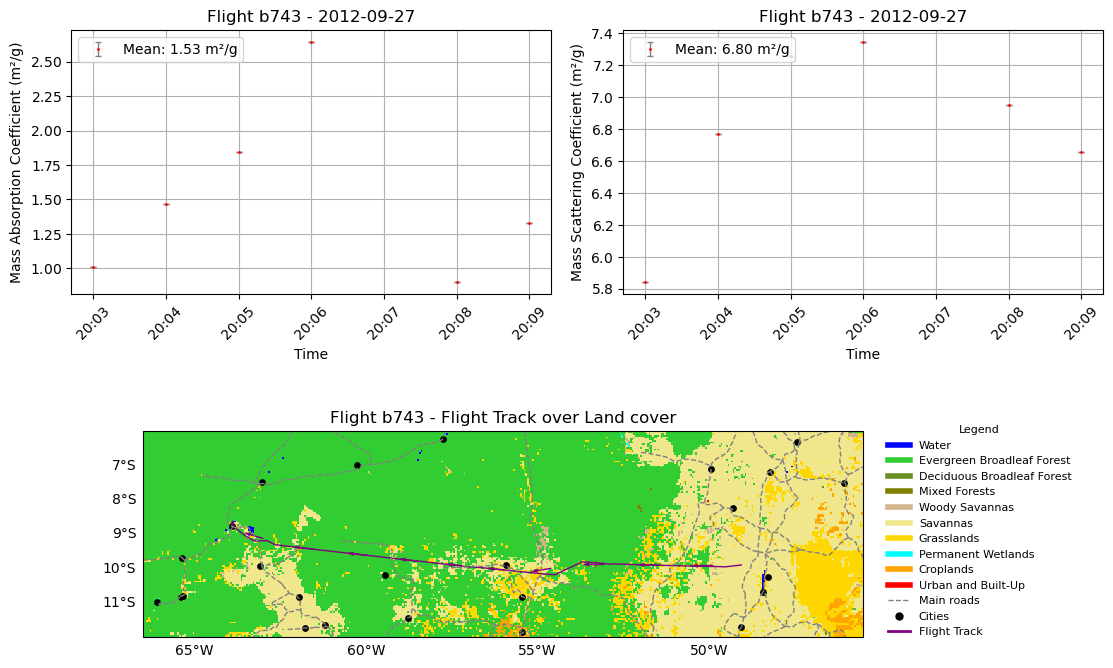

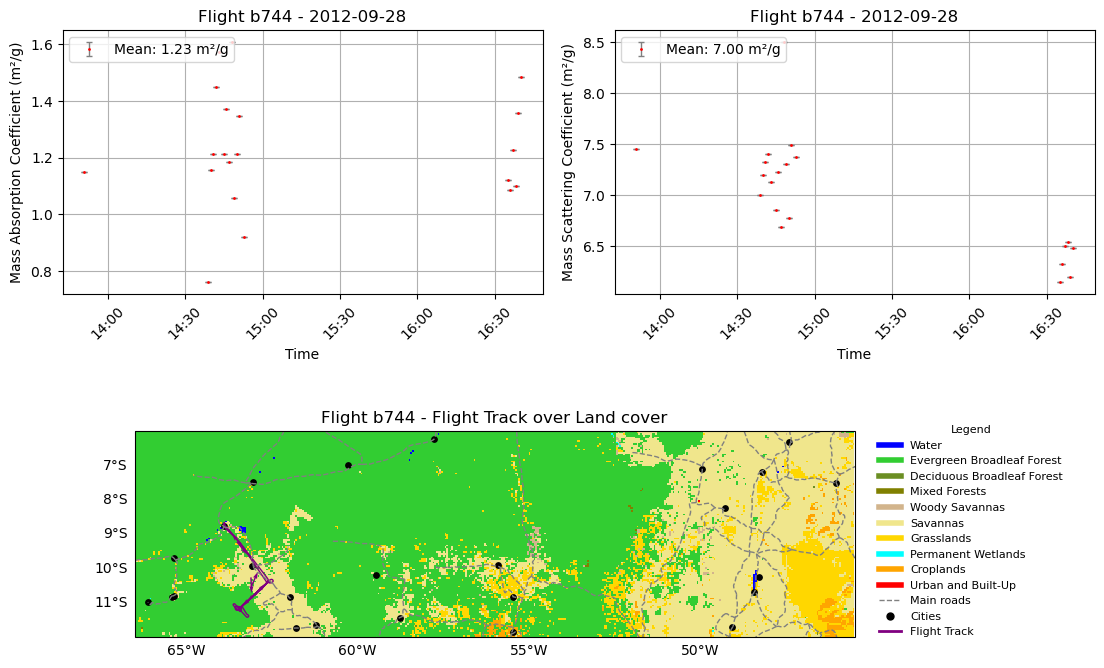

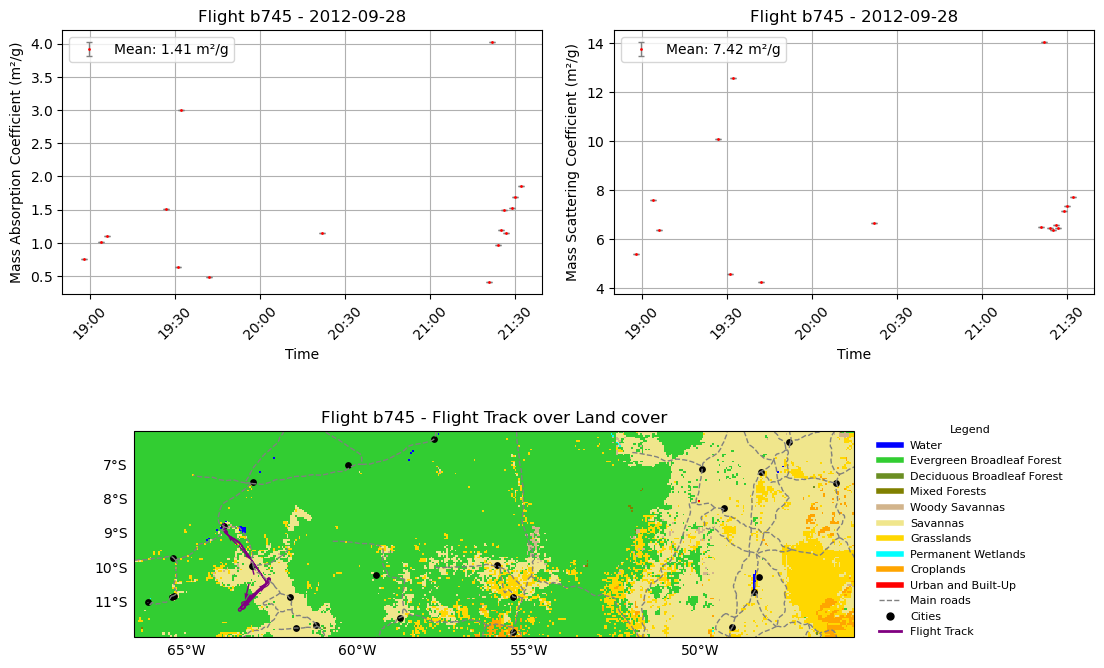

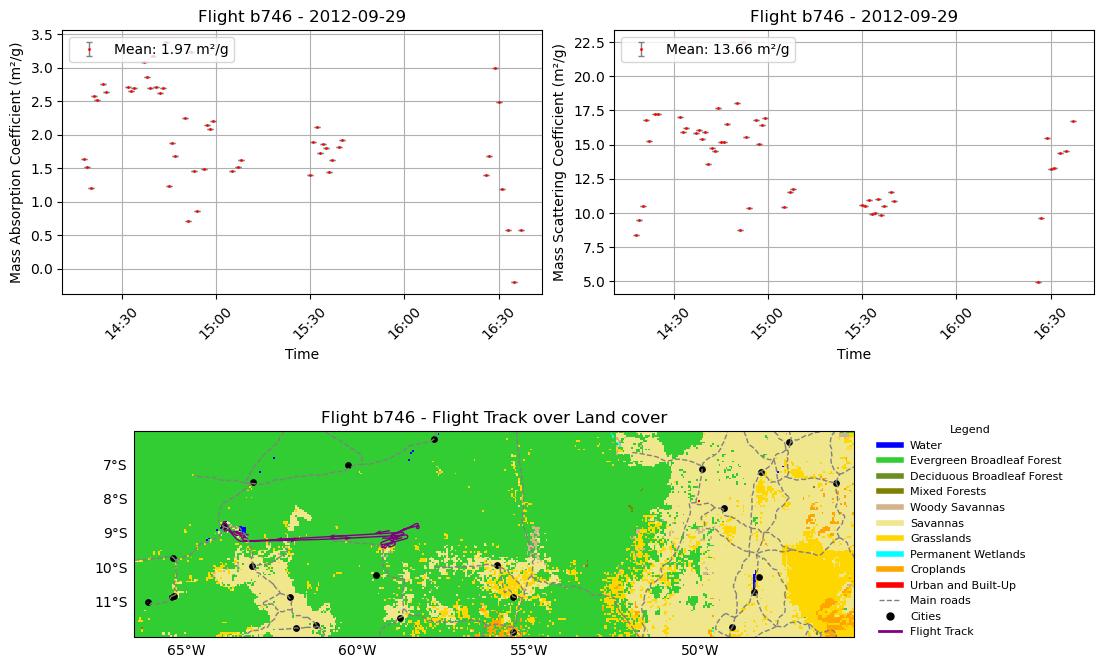

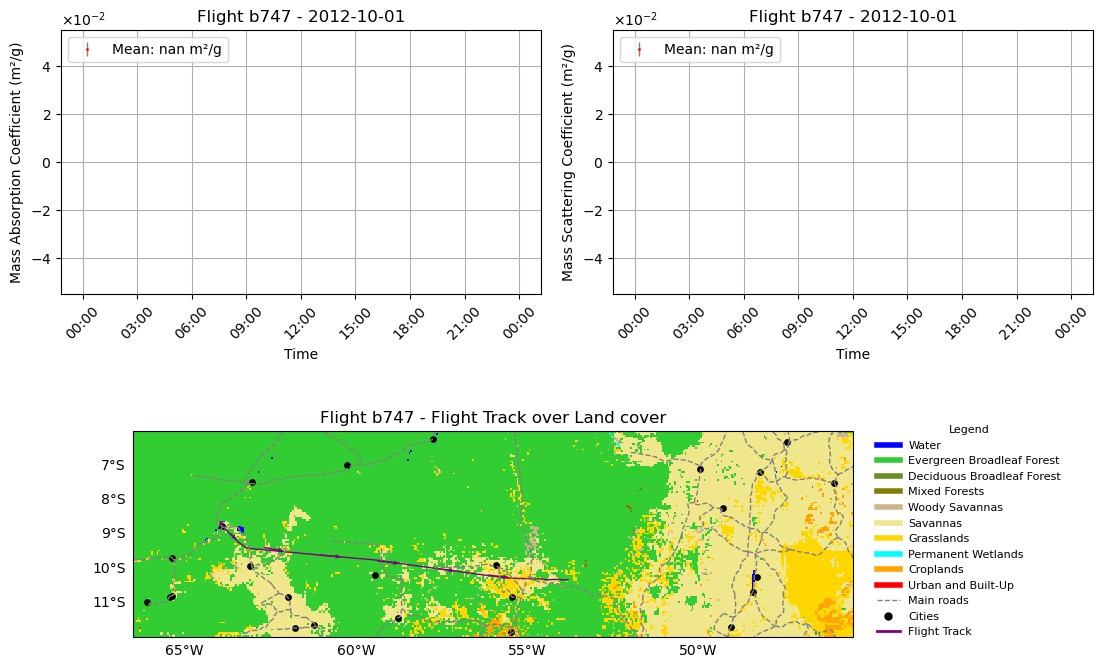

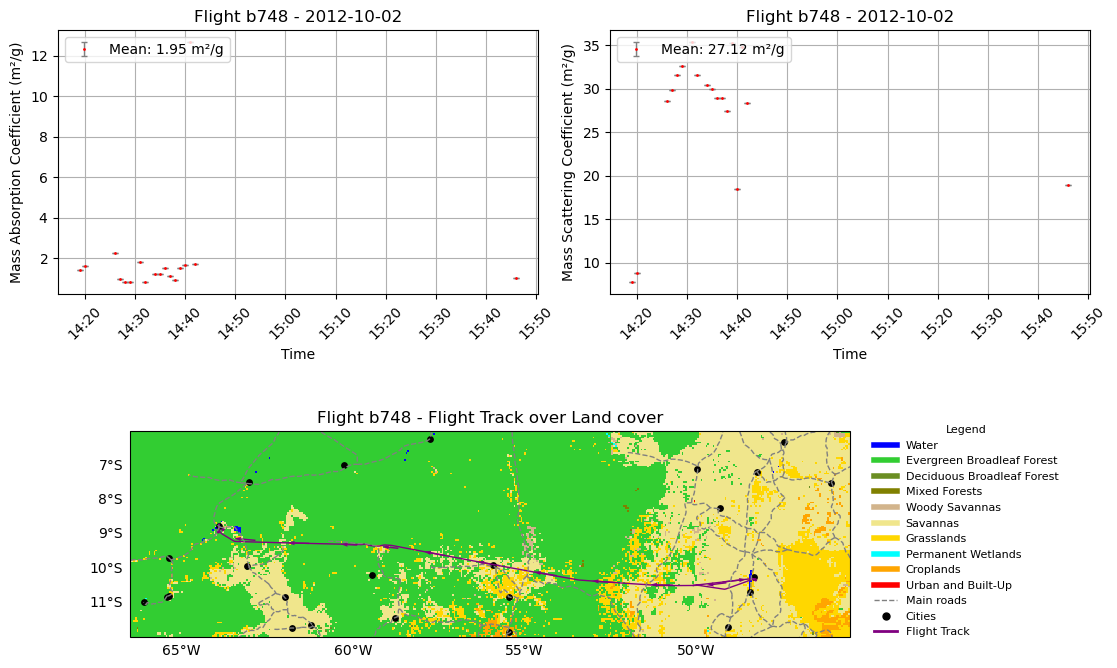

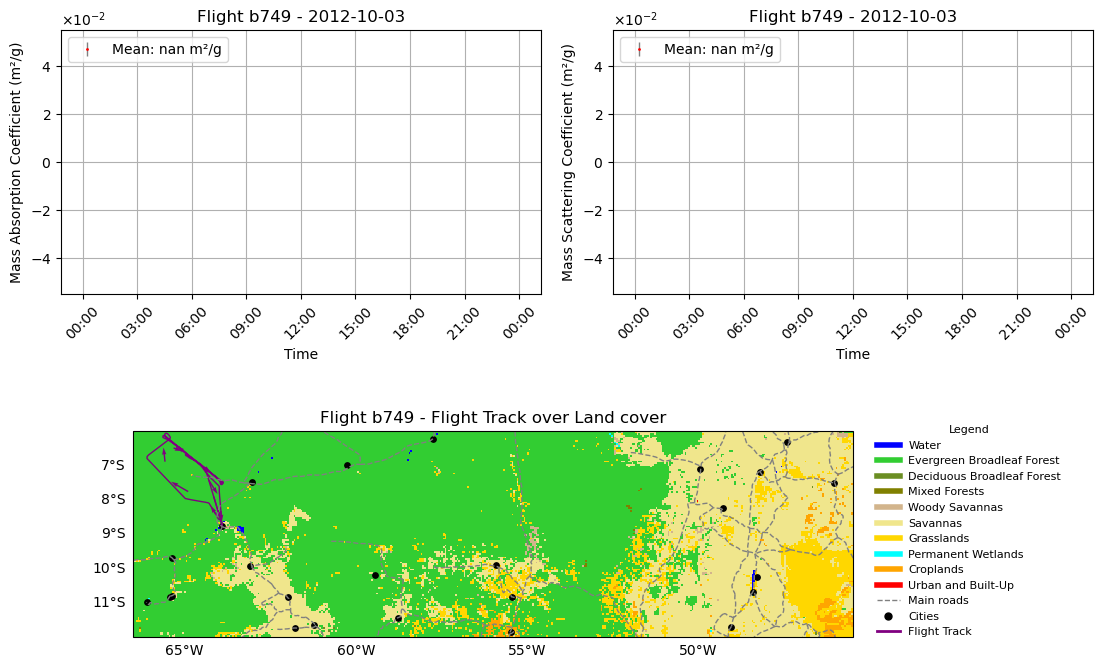

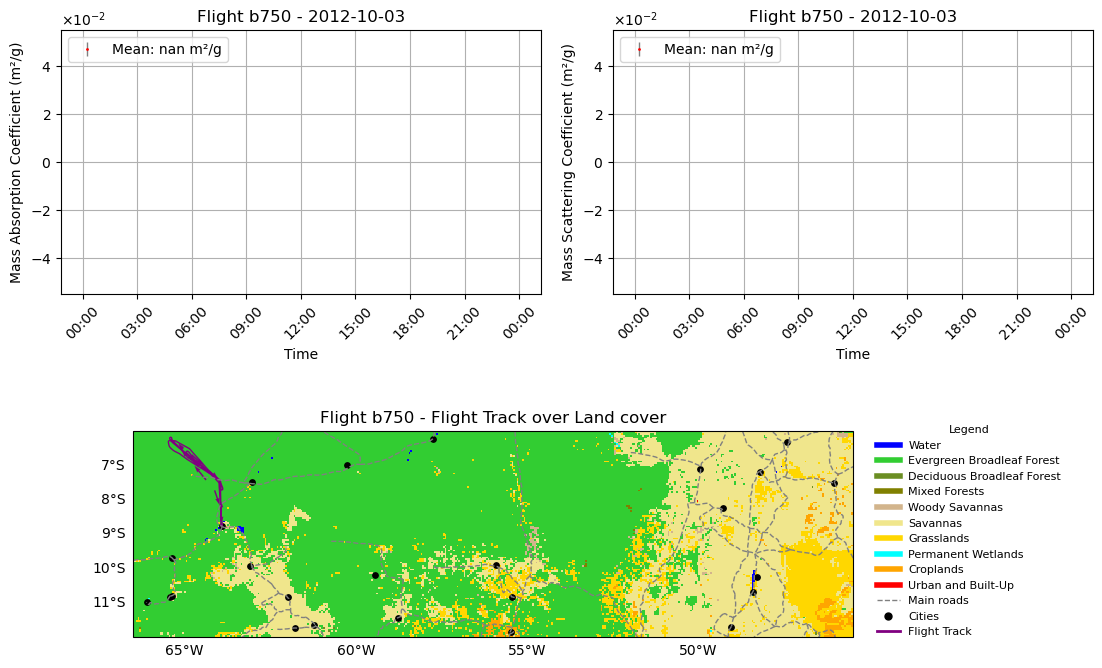

In [33]:
# List to store results
results_abs = []
results_sct = []

# Iterate over all matching flights
for sp2_file, ams_file, nc_file, neph_file, flight_comments_file in zip(filtered_sp2, filtered_ams, filtered_nc, filtered_neph,filtered_sum):

    print(neph_file)
    ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(sp2_file,ams_file,neph_file)
    ds_psap = xr.open_dataset(nc_file)

    #Calculate absortion efficiency 
    ds_psap_matched,tm_psap_match,tm_psap_match_unc,test=calculate_absortion_eff_v3(ds_sp2,ds_ams,ds_psap)

    #Calculate Scattering efficiency 
    ds_neph_matched_un,tm_neph_match,tm_neph_match_unc=calculate_scatering_eff_v2(ds_sp2,ds_ams,ds_neph)

    #Extract concentration data
    #area_time,data_mass_concentration = Area_plot(ds_sp2,ds_ams,ds_psap)

    #Filter absortion data
    #valid_neph_mask = ~np.isnan(ds_neph_matched["TSC_BLUU"])
    #filtered_ds_neph = ds_neph_matched.where(valid_PSAP_mask, drop=TRUE)

    #Filter absortion data
    #valid_PSAP_mask = ds_psap_matched["PSAP_LIN_FLAG"] == 0
    #filtered_ds_psap = ds_psap_matched.where(valid_PSAP_mask, drop=False)
    #filtered_ds_psap_aux = ds_psap_matched.where(valid_PSAP_mask, drop=False)
    # Ensure both arrays are 1D and aligned
    #psap_values = filtered_ds_psap["PSAP_LIN"]
    #tm_values_psap_match = tm_psap_match.values

    #Filter CO and Hight data
    ds_psap_matched_time = test["data_point"].values  # Reference timestamps
    ds_neph_matched_time = ds_neph_matched_un["time"].values
    common_times = np.intersect1d(ds_psap_matched_time, ds_neph_matched_time)

    #ds_psap_matched = test.sel(data_point=common_times)
    ds_neph_matched = ds_neph_matched_un.sel(time=common_times)
    tm_neph_match = tm_neph_match.sel(time=common_times)
    #mask = ds_psap_matched_un["PSAP_LIN"].notnull()
    #ds_neph_matched = ds_neph_matched_un.where(mask, drop=True)

    # Ensure both arrays are 1D and aligned
    #neph_values = ds_neph_matched["TSC_BLUU"].values.squeeze()
    #datetimes = ds_neph_matched["Times"]#.values.squeeze()
    #tm_values_neph_match = tm_neph_match.squeeze()
 
    # Perform element-wise division, ignoring NaNs
    #result_abs = np.divide(psap_values, tm_values_psap_match*1e-6)
    result_abs = np.divide(ds_psap_matched['PSAP_LIN'].values.squeeze(), tm_psap_match*1e-6)
    # Perform element-wise division, ignoring NaNs
    result_sct = np.divide(ds_neph_matched["TSC_BLUU"].values.squeeze(), tm_neph_match*1e-6)
    
    # Compute uncertainty in the absorption efficiency (only considering uncertainty in total_mass)
    rel_uncertainty_mass = (tm_psap_match_unc * 1e-6) / tm_psap_match
    abs_coeff_uncertainty = np.abs(result_abs * rel_uncertainty_mass)

    # Compute uncertainty in the scattering efficiency (only considering uncertainty in total_mass)
    rel_uncertainty_mass_sct = (tm_neph_match_unc * 1e-6) / tm_neph_match
    sct_coeff_uncertainty = np.abs(result_sct * rel_uncertainty_mass_sct)
    

    # Drop NaN values from the result if needed
    Mass_absortion_eff = result_abs.where(~np.isnan(result_abs), drop=True)
    abs_coeff_uncertainty = abs_coeff_uncertainty.where(~np.isnan(abs_coeff_uncertainty), drop=True)

    # Drop NaN values from the result if needed
    Mass_scattering_eff = result_sct.where(~np.isnan(result_sct), drop=False)
    sct_coeff_uncertainty = sct_coeff_uncertainty.where(~np.isnan(sct_coeff_uncertainty), drop=False)

    # Compute the mean, handling cases where the list might be empty
    mean_mass_absorption_eff_g = np.nanmean(Mass_absortion_eff) 
    std_mass_absorption_eff_g = np.nanstd(Mass_absortion_eff) 
    mean_std_abs = std_mass_absorption_eff_g/np.sqrt(len(Mass_absortion_eff))

    # Compute the mean, handling cases where the list might be empty
    mean_mass_scattering_eff_g = np.nanmean(Mass_scattering_eff) 
    std_mass_scattering_eff_g = np.nanstd(Mass_scattering_eff) 
    mean_std_sct = std_mass_scattering_eff_g/np.sqrt(len(Mass_scattering_eff))
    

    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', nc_file)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"
    # Extract the date in yyyymmdd format
    date_match = re.search(r'(\d{8})', nc_file)
    if date_match:
        date_str = date_match.group(1)
        flight_date = datetime.strptime(date_str, "%Y%m%d").strftime("%Y-%m-%d")
    else:
        flight_date = "Unknown"


    plot_results_data_v3( 
        flight_number=flight_number,
        flight_date = flight_date,
        abs_coeff_uncertainty=abs_coeff_uncertainty,
        Mass_absortion_eff=Mass_absortion_eff,
        ds_neph_datetime=ds_neph_matched,
        Mass_scattering_eff=Mass_scattering_eff,
        sct_coeff_uncertainty = sct_coeff_uncertainty,
        mean_abs_eff = mean_mass_absorption_eff_g,
        mean_sct_eff = mean_mass_scattering_eff_g)

    # Store results in a list
    results_abs.append({
        "flight": flight_number,
        "mean_mass_absorption_eff_g": mean_mass_absorption_eff_g,
        "std_mass_absorption_eff_g": std_mass_absorption_eff_g,
        "mean_std": mean_std_abs,
        "N": len(Mass_absortion_eff)
    })

    # Store results in a list
    results_sct.append({
        "flight": flight_number,
        "mean_mass_scattering_eff_g": mean_mass_scattering_eff_g,
        "std_mass_scattering_eff_g": std_mass_scattering_eff_g,
        "mean_std": mean_std_sct,
        "N": len(Mass_scattering_eff)
    })

In [ ]:
# Print results
for res in results_abs:
    print(f"Flight {res['flight']}: {res['mean_mass_absorption_eff_g']:.3f} m²/g")

In [ ]:
# Print results
for res in results_sct:
    print(f"Flight {res['flight']}: {res['mean_mass_scattering_eff_g']:.3f} m²/g")

In [ ]:
# Extract flight numbers, mean values, standard deviation, and N
flight_numbers = [res["flight"] for res in results_abs]
mean_mass_absorption_eff_g_values = [res["mean_mass_absorption_eff_g"] for res in results_abs]
mean_std_values = [res["mean_std"] for res in results_abs]  # Error bars
n_values = [res["N"] for res in results_abs]  # Number of measurements

# Compute overall mean of the means
overall_mean = np.nanmean(mean_mass_absorption_eff_g_values)  # use nanmean in case of NaNs

# Create the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(
    flight_numbers,
    mean_mass_absorption_eff_g_values,
    yerr=mean_std_values,  # Add error bars
    capsize=5,
    color='royalblue',
    alpha=0.75,
    label=f'Overall mean: {overall_mean:.2f} m²/g'  # Add to legend
)

# Labels and title
plt.xlabel("Flights", fontsize=12)
plt.ylabel("Mean Mass Absorption Efficiency (m²/g)", fontsize=12)
plt.title("Mass Absorption Efficiency per Flight", fontsize=14)
plt.xticks(rotation=90)

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text inside the bars to show N
for bar, n in zip(bars, n_values):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,
        f"N=\n{n}",
        ha='center',
        va='center',
        fontsize=8,
        color='white',
        fontweight='bold'
    )

# Add legend
plt.legend(loc='upper right')

# Save the plot
plt.savefig('Absortion_efficiency_v3.png')

In [ ]:
# Extract flight numbers, mean values, standard deviation, and N
flight_numbers = [res["flight"] for res in results_sct]
mean_mass_scattering_eff_g_values = [res["mean_mass_scattering_eff_g"] for res in results_sct]
mean_std_values = [res["mean_std"] for res in results_sct]  # Error bars
n_values = [res["N"] for res in results_sct]  # Number of measurements

# Compute overall mean
overall_mean = np.nanmean(mean_mass_scattering_eff_g_values)

# Create the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(
    flight_numbers,
    mean_mass_scattering_eff_g_values,
    yerr=mean_std_values,  # Add error bars
    capsize=5,
    color='royalblue',
    alpha=0.75,
    label=f'Overall mean: {overall_mean:.2f} m²/g'  # Include mean in legend
)

# Labels and title
plt.xlabel("Flights", fontsize=12)
plt.ylabel("Mean Mass Scattering Efficiency (m²/g)", fontsize=12)
plt.title("Mass Scattering Efficiency per Flight", fontsize=14)
plt.xticks(rotation=90)

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text inside the bars to show N
for bar, n in zip(bars, n_values):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,
        f"N=\n{n}",
        ha='center',
        va='center',
        fontsize=8,
        color='white',
        fontweight='bold'
    )

# Add legend
plt.legend(loc='upper right')

# Save the plot
plt.savefig('Scattering_efficiency_v3.png')

In [ ]:
# Exclude the maximum value
ssa_array = np.array(mean_mass_scattering_eff_g_values)
ssa_without_max = ssa_array[ssa_array != np.nanmax(ssa_array)]
mean_ssa_excl_max = np.nanmean(ssa_without_max)
print(mean_ssa_excl_max)